# Wildfire Training Notebook (XGBoost-LGBM Blend)

Train next-day California wildfire risk on Kaggle Input packs (`knn` or `median`).

Flow: configure → validate → preprocess → features → split → pipeline + Optuna → train → validate/calibrate → feature importance → export.

## 1. Load, Import & Configuration

Set `DATA_SOURCE` (`knn` / `median`) and `CELL_SUBSET`. Uses fixed Kaggle paths; prefers `train.parquet` + `val.parquet`.


In [3]:
!pip install lightgbm xgboost --config-settings=cmake.define.USE_CUDA=1


In [4]:
from __future__ import annotations

import gc
import hashlib
import json
import math
import os
import platform
import subprocess
import tempfile
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "wildfire-mpl"))
os.environ.setdefault("MPLBACKEND", "Agg")

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import sklearn
from sklearn import set_config
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

SEED = 42

def env_get(*names: str, default: str = "") -> str:
    for name in names:
        value = os.environ.get(name)
        if value is not None and str(value).strip() != "":
            return str(value).strip()
    return default

# knn → california-wildfire-knn | median → california-wildfire-median
DATA_SOURCE = "knn"  # change to "median" for the median pack
DATA_SOURCE = env_get("WILDFIRE_DATA_SOURCE", "CHAMPION_DATA_SOURCE", default=DATA_SOURCE).lower()
if DATA_SOURCE in {"stage_c_knn", "knn"}:
    DATA_SOURCE = "knn"
elif DATA_SOURCE in {"stage_c", "median"}:
    DATA_SOURCE = "median"
else:
    raise ValueError("DATA_SOURCE must be 'knn' or 'median'")

_DATA_PATHS = {
    "knn": "/kaggle/input/datasets/lakshay654/california-wildfire-knn",
    "median": "/kaggle/input/datasets/lakshay654/california-wildfire-median",
}
DATA_DIRECTORY = env_get("WILDFIRE_DATA_DIR", "CHAMPION_DATA_DIR", default=_DATA_PATHS[DATA_SOURCE])
TRAINING_DATA_STAGE = "stage_c_knn" if DATA_SOURCE == "knn" else "stage_c"
USE_PRECOMPUTED_KNN = DATA_SOURCE == "knn"
IMPUTATION_METHOD = "precomputed KNN" if USE_PRECOMPUTED_KNN else "training-only median"

CELL_SUBSET = "high_medium_fire"  # all | high_fire | high_medium_fire
CELL_SUBSET = env_get("WILDFIRE_CELL_SUBSET", "CHAMPION_CELL_SUBSET", default=CELL_SUBSET)
if CELL_SUBSET not in {"all", "high_fire", "high_medium_fire"}:
    raise ValueError("CELL_SUBSET must be 'all', 'high_fire', or 'high_medium_fire'")
CELL_SUBSET_CATEGORIES = {
    "all": None,
    "high_fire": ["High Outlier", "High"],
    "high_medium_fire": ["High Outlier", "High", "Medium"],
}
FIRE_REGION_CSV = env_get(
    "WILDFIRE_FIRE_REGION_CSV",
    "CHAMPION_FIRE_REGION_CSV",
    default="/kaggle/input/datasets/lakshay654/firms-test/fire_analysis2.csv",
)
USE_SPLIT_FILES = env_get("WILDFIRE_USE_SPLIT_FILES", default="1").lower() not in {"0", "false", "no"}

MODE = env_get("WILDFIRE_MODE", "CHAMPION_MODE", default="full").lower()
if MODE not in {"full", "smoke"}:
    raise ValueError("MODE must be 'full' or 'smoke'")
USE_GPU = env_get("WILDFIRE_USE_GPU", "CHAMPION_USE_GPU", default="1").lower() not in {"0", "false", "no"}
np.random.seed(SEED)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
set_config(display="diagram")

def show(value: Any) -> None:
    try:
        from IPython.display import display
        display(value)
    except ImportError:
        print(value)

def show_image(path: Path) -> None:
    try:
        from IPython.display import Image, display
        display(Image(filename=str(path)))
    except ImportError:
        print(f"Saved image: {path}")

def pack_paths(root: Path) -> dict[str, Path] | None:
    root = root.resolve()
    flat_meta = root / "dataset_metadata.json"
    nested_meta = root / "metadata" / "dataset_metadata.json"
    if flat_meta.is_file():
        meta = flat_meta
        features = root / "feature_columns.json"
    elif nested_meta.is_file():
        meta = nested_meta
        features = root / "metadata" / "feature_columns.json"
    else:
        return None
    has_table = (root / "all.parquet").is_file() or (
        (root / "train.parquet").is_file() and (root / "val.parquet").is_file()
    )
    if not has_table or not (root / "meta.json").is_file() or not features.is_file():
        return None
    try:
        stage = json.loads(meta.read_text(encoding="utf-8")).get("stage")
    except (OSError, json.JSONDecodeError):
        return None
    if stage != TRAINING_DATA_STAGE:
        return None
    return {
        "root": root,
        "meta": root / "meta.json",
        "dataset_metadata": meta,
        "features": features,
        "all": root / "all.parquet",
        "train": root / "train.parquet",
        "val": root / "val.parquet",
        "test": root / "test.parquet",
    }

def resolve_data_pack() -> dict[str, Path]:
    candidates = [
        Path(DATA_DIRECTORY).expanduser(),
        Path(_DATA_PATHS[DATA_SOURCE]),
        Path.cwd(),
        Path.cwd() / ("stage_c_knn" if DATA_SOURCE == "knn" else "stage_c"),
    ]
    # Local Milestone 5 flat packs and Milestone 4 shared cache.
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        candidates.append(base / "Milestone 5" / "kaggle_datasets" / ("stage_c_knn" if DATA_SOURCE == "knn" else "stage_c"))
        candidates.append(base / "Milestone 4" / "numerical_nextday" / "outputs" / "m4_shared_cache" / ("stage_c_knn" if DATA_SOURCE == "knn" else "stage_c"))
    checked = []
    for root in candidates:
        checked.append(str(root))
        found = pack_paths(root)
        if found is not None:
            return found
    raise FileNotFoundError(
        f"Could not find {DATA_SOURCE} pack (stage={TRAINING_DATA_STAGE}). "
        f"Set DATA_DIRECTORY. Tried:\n" + "\n".join(f"  - {item}" for item in checked)
    )

DATA_PACK = resolve_data_pack()
DATA_ROOT = DATA_PACK["root"]
META_JSON = DATA_PACK["meta"]
DATASET_METADATA_JSON = DATA_PACK["dataset_metadata"]
FEATURE_COLUMNS_JSON = DATA_PACK["features"]
ALL_PARQUET = DATA_PACK["all"]
TRAIN_PARQUET = DATA_PACK["train"]
VAL_PARQUET = DATA_PACK["val"]
TEST_PARQUET = DATA_PACK["test"]

USE_SPLIT = bool(
    USE_SPLIT_FILES and TRAIN_PARQUET.is_file() and VAL_PARQUET.is_file()
)
if USE_SPLIT:
    LOAD_MODE = "train+val split files"
    TABLE_PARQUETS = [TRAIN_PARQUET, VAL_PARQUET]
else:
    if not ALL_PARQUET.is_file():
        raise FileNotFoundError(f"Need train+val parquet or all.parquet under {DATA_ROOT}")
    LOAD_MODE = "all.parquet (years <= 2024)"
    TABLE_PARQUETS = [ALL_PARQUET]

default_output = (
    Path(f"/kaggle/working/wildfire_training_outputs_{DATA_SOURCE}_{CELL_SUBSET}")
    if Path("/kaggle/working").is_dir()
    else Path.cwd() / "notebook_outputs" / f"wildfire_training_{DATA_SOURCE}_{CELL_SUBSET}_{MODE}"
)
OUTPUT_DIR = Path(env_get("WILDFIRE_OUTPUT_DIR", "CHAMPION_OUTPUT_DIR", default=str(default_output))).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "metrics").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)

def reported_gpu() -> str | None:
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
            check=True, capture_output=True, text=True, timeout=10,
        )
        values = [line.strip() for line in result.stdout.splitlines() if line.strip()]
        return ", ".join(values) if values else None
    except (FileNotFoundError, subprocess.SubprocessError):
        return None

def lightgbm_device() -> tuple[str, dict[str, str]]:
    if not USE_GPU:
        return "cpu", {"cpu": "GPU disabled"}
    rng = np.random.default_rng(SEED)
    x = rng.normal(size=(2000, 20)).astype("float32")
    y = rng.integers(0, 2, size=2000, dtype="int8")
    failures: dict[str, str] = {}
    for device in ("cuda", "gpu"):
        try:
            dataset = lgb.Dataset(x, label=y)
            lgb.train(
                {"objective": "binary", "device_type": device, "verbosity": -1, "seed": SEED},
                dataset, num_boost_round=2,
            )
            return device, failures
        except Exception as error:
            failures[device] = str(error).splitlines()[-1][:400]
    return "cpu", failures

DEVICE, DEVICE_FAILURES = lightgbm_device()
GPU_NAME = reported_gpu()

print("=" * 72)
print("WILDFIRE TRAINING CONFIGURATION")
print("=" * 72)
print(f"Data source:       {DATA_SOURCE} ({TRAINING_DATA_STAGE})")
print(f"Cell subset:       {CELL_SUBSET}")
print(f"Imputation:        {IMPUTATION_METHOD}")
print(f"Mode:              {MODE}")
print(f"Load mode:         {LOAD_MODE}")
print(f"Input directory:   {DATA_ROOT}")
print(f"test.parquet used: no (reserved for inference)")
print(f"Output directory:  {OUTPUT_DIR}")
print(f"Reported GPU:      {GPU_NAME or 'not reported'}")
print(f"LightGBM device:   {DEVICE}")
if USE_GPU and DEVICE == "cpu":
    print("GPU requested but unavailable; using CPU.")
    for name, message in DEVICE_FAILURES.items():
        print(f"  {name}: {message}")
print("=" * 72)


[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


WILDFIRE TRAINING CONFIGURATION
Data source:       knn (stage_c_knn)
Cell subset:       high_medium_fire
Imputation:        precomputed KNN
Mode:              full
Load mode:         train+val split files
Input directory:   /kaggle/input/datasets/lakshay654/california-wildfire-knn
test.parquet used: no (reserved for inference)
Output directory:  /kaggle/working/wildfire_training_outputs_knn_high_medium_fire
Reported GPU:      Tesla T4, Tesla T4
LightGBM device:   gpu


## 2. Data Validation

Checks metadata stage, schema, required columns, and KNN donor contract when using the KNN pack.


In [5]:
# 1. Load feature allowlist from feature_columns.json
with open(FEATURE_COLUMNS_JSON, "r", encoding="utf-8") as f:
  raw_features = json.load(f)

# 2. Add precomputed KNN flag if applicable
missing_flag_column = "s2n_knn_imputed" if USE_PRECOMPUTED_KNN else None
model_source_features = list(
    dict.fromkeys(
        [*raw_features, *([missing_flag_column] if missing_flag_column else [])]
    )
)

# 3. Define metadata & required ID columns
ID_COLUMNS = [
    "feature_end_date",
    "eo_asof_date",
    "label_date",
    "cell_id",
    "latitude",
    "longitude",
    "y_fire",
]
AGE_COLUMNS = ["s2n_lag_days", "s5n_lag_days"]

# Combined list of columns to load from parquet files
load_columns = list(
    dict.fromkeys([*ID_COLUMNS, *AGE_COLUMNS, *model_source_features])
)

print(
    f"Feature contract loaded: {len(model_source_features)} features | Total"
    f" load columns: {len(load_columns)}"
)


Feature contract loaded: 64 features | Total load columns: 73


## 3. Preprocessing

Loads train+val (or `all` ≤2024), applies KNN pass-through or median-ready missing marks, optional fire-region cell filter.


fire_analysis2.csv category counts: {'Medium': 293, 'Low': 140, 'High': 115, 'High Outlier': 31}
CELL_SUBSET=high_medium_fire: categories=['High Outlier', 'High', 'Medium'] selected_cells=437 csv_only_not_in_stage_c=2
Loaded subset: cells=437 days=2,557 rows=1,117,409 positives=21,069 CELL_SUBSET=high_medium_fire


,rows,positives,days,positive_rate
year,,,,
2019,159505,2308,365,1.447%
2020,159942,4692,366,2.934%
2021,159505,4115,365,2.580%
2022,159505,2392,365,1.500%
2023,159505,2934,365,1.839%
2024,159942,2426,366,1.517%
2025,159505,2202,365,1.381%


{
  "knn_imputed_rows_flagged": 2185,
  "swvl1_mean_negative_rows_clipped": 3108,
  "swvl2_mean_negative_rows_clipped": 4398,
  "soil_moisture_index_negative_rows_clipped": 1066,
  "swvl1_mean_7d_negative_rows_clipped": 2250
}
Loaded 1,117,409 rows in 8.7s


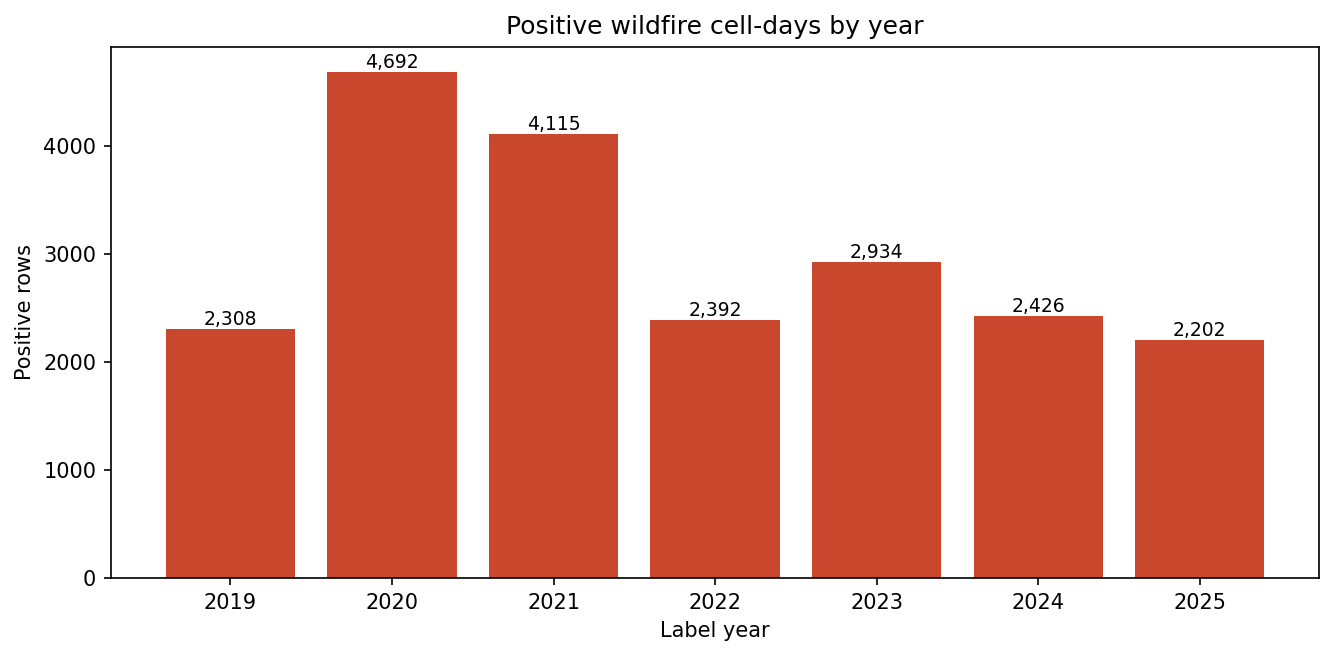

In [6]:
CONSTANT_FEATURES = {"s5n_s5p_aai_std", "s5n_s5p_co_std"}
base_features = [name for name in model_source_features if name not in CONSTANT_FEATURES]
load_columns = list(dict.fromkeys([*ID_COLUMNS, *AGE_COLUMNS, *model_source_features]))

def clean_source_table(frame: pd.DataFrame, raw_base_features: list[str]):
    """Apply only the preprocessing appropriate to the selected source stage."""
    frame = frame.copy()
    for name in ("feature_end_date", "eo_asof_date", "label_date"):
        frame[name] = pd.to_datetime(frame[name]).dt.normalize()
    frame = frame.sort_values(["cell_id", "label_date"]).reset_index(drop=True)
    cleanup_counts: dict[str, int] = {}

    if USE_PRECOMPUTED_KNN:
        frame[raw_base_features] = frame[raw_base_features].apply(pd.to_numeric, errors="raise").astype("float32")
        flag_values = set(frame[missing_flag_column].dropna().unique().tolist())
        if not flag_values.issubset({0.0, 1.0}):
            raise ValueError(f"{missing_flag_column} must be binary; found {sorted(flag_values)}")
        if not np.isfinite(frame[raw_base_features].to_numpy(dtype="float32", copy=False)).all():
            raise ValueError("Precomputed KNN values contain NaN or infinity")
        flagged = frame[missing_flag_column].eq(1)
        if not frame.loc[flagged, "s2n_available"].eq(0).all():
            raise ValueError("Every KNN-imputed S2 row must retain s2n_available=0")
        cleanup_counts["knn_imputed_rows_flagged"] = int(flagged.sum())
    else:
        s2_invalid = frame["s2n_available"].ne(1)
        s2_values = [name for name in raw_base_features if name.startswith("s2n_") and name != "s2n_available"]
        frame.loc[s2_invalid, s2_values] = np.nan
        frame.loc[s2_invalid, "s2n_available"] = 0.0
        cleanup_counts["sentinel2_rows_marked_missing"] = int(s2_invalid.sum())
        s5_invalid = frame["s5n_available"].ne(1)
        s5_values = [name for name in raw_base_features if name.startswith("s5n_") and name != "s5n_available"]
        frame.loc[s5_invalid, s5_values] = 0.0
        frame.loc[s5_invalid, "s5n_available"] = 0.0
        cleanup_counts["sentinel5p_rows_zeroed"] = int(s5_invalid.sum())
        frame[raw_base_features] = frame[raw_base_features].astype("float32")

    for name in ("swvl1_mean", "swvl2_mean", "soil_moisture_index", "swvl1_mean_7d"):
        cleanup_counts[f"{name}_negative_rows_clipped"] = int(frame[name].lt(0).sum())
        frame[name] = frame[name].clip(lower=0)
    frame["year"] = frame["label_date"].dt.year.astype("int16")
    return frame, cleanup_counts

started = time.time()
def resolve_fire_region_csv() -> Path:
    configured = (FIRE_REGION_CSV or "").strip()
    candidates: list[Path] = []
    if configured:
        candidates.append(Path(configured).expanduser())
    candidates.append(Path("/kaggle/input/datasets/lakshay654/firms-test/fire_analysis2.csv"))
    candidates.append(Path.cwd() / "fire_analysis2.csv")
    # Notebook / Milestone 5 directory heuristics
    here = Path.cwd().resolve()
    candidates.extend([
        here / "Milestone 5" / "fire_analysis2.csv",
        here.parent / "Milestone 5" / "fire_analysis2.csv",
    ])
    for base in (here, *here.parents):
        candidates.append(base / "fire_analysis2.csv")
        candidates.append(base / "Milestone 5" / "fire_analysis2.csv")
    if Path("/kaggle/input").is_dir():
        candidates.extend(Path("/kaggle/input").rglob("fire_analysis2.csv"))
    seen: set[Path] = set()
    for path in candidates:
        path = path.resolve()
        if path in seen:
            continue
        seen.add(path)
        if path.is_file():
            return path
    raise FileNotFoundError(
        "fire_analysis2.csv not found for CELL_SUBSET="
        f"{CELL_SUBSET}. Set FIRE_REGION_CSV or attach the CSV under /kaggle/input."
    )


def cells_for_subset(csv_path: Path, categories: list[str], available_cells: list) -> list:
    frame = pd.read_csv(csv_path)
    required = {"cell_id", "fire_region_category"}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"fire_analysis2.csv missing columns: {sorted(missing)}")
    frame["cell_id"] = frame["cell_id"].astype(str)
    available = {str(cell) for cell in available_cells}
    counts = frame["fire_region_category"].value_counts(dropna=False).to_dict()
    print("fire_analysis2.csv category counts:", counts)
    allow = set(
        frame.loc[frame["fire_region_category"].isin(categories), "cell_id"].astype(str)
    )
    selected = [cell for cell in available_cells if str(cell) in allow]
    if not selected:
        raise ValueError(
            f"No Stage C cells matched CELL_SUBSET={CELL_SUBSET} categories={categories}"
        )
    unmatched_csv = sorted(allow - available)
    print(
        f"CELL_SUBSET={CELL_SUBSET}: categories={categories} "
        f"selected_cells={len(selected)} "
        f"csv_only_not_in_stage_c={len(unmatched_csv)}"
    )
    return selected


cell_table = pd.read_parquet(ALL_PARQUET, columns=["cell_id"])
archive_cells = sorted(cell_table["cell_id"].unique().tolist())
selected_cells = list(archive_cells)
FIRE_REGION_CSV_PATH = None
if MODE == "smoke":
    positions = np.linspace(0, len(selected_cells) - 1, min(96, len(selected_cells)), dtype=int)
    selected_cells = list(dict.fromkeys(selected_cells[position] for position in positions))
if CELL_SUBSET != "all":
    FIRE_REGION_CSV_PATH = resolve_fire_region_csv()
    selected_cells = cells_for_subset(
        FIRE_REGION_CSV_PATH,
        CELL_SUBSET_CATEGORIES[CELL_SUBSET],
        selected_cells,
    )
del cell_table
gc.collect()

SELECTED_TRAINING_CELLS = list(selected_cells)
CELL_SUBSET_INFO = {
    "cell_subset": CELL_SUBSET,
    "categories": CELL_SUBSET_CATEGORIES[CELL_SUBSET],
    "n_cells_selected": len(SELECTED_TRAINING_CELLS),
    "n_archive_cells": len(archive_cells),
    "fire_region_csv": str(FIRE_REGION_CSV_PATH) if FIRE_REGION_CSV_PATH else None,
}

if len(SELECTED_TRAINING_CELLS) == len(archive_cells) and CELL_SUBSET == "all" and MODE != "smoke":
    data = pd.read_parquet(ALL_PARQUET, columns=load_columns)
else:
    data = pd.read_parquet(
        ALL_PARQUET,
        columns=load_columns,
        filters=[("cell_id", "in", SELECTED_TRAINING_CELLS)],
    )

data, cleanup = clean_source_table(data, base_features)
cells = int(data["cell_id"].nunique())
days = int(data["label_date"].nunique())
assert len(data) == cells * days
assert data.duplicated(["cell_id", "label_date"]).sum() == 0
assert sorted(data["y_fire"].unique().tolist()) == [0, 1]
assert (data["label_date"] - data["eo_asof_date"]).dt.days.eq(1).all()
assert (data["eo_asof_date"] - data["feature_end_date"]).dt.days.eq(5).all()
if cells != len(SELECTED_TRAINING_CELLS):
    raise ValueError(
        f"Loaded cells ({cells}) do not match selected subset ({len(SELECTED_TRAINING_CELLS)})"
    )
print(
    f"Loaded subset: cells={cells:,} days={days:,} rows={len(data):,} "
    f"positives={int(data['y_fire'].sum()):,} CELL_SUBSET={CELL_SUBSET}"
)
if USE_PRECOMPUTED_KNN and MODE == "full" and CELL_SUBSET == "all":
    if cleanup["knn_imputed_rows_flagged"] != int(dataset_meta["n_s2_knn_imputed"]):
        raise ValueError("Full KNN flag count does not match metadata")

yearly_quantity = data.groupby("year").agg(
    rows=("y_fire", "size"), positives=("y_fire", "sum"), days=("label_date", "nunique"),
)
yearly_quantity["positive_rate"] = yearly_quantity["positives"] / yearly_quantity["rows"]
yearly_quantity_display = yearly_quantity.copy()
yearly_quantity_display["positive_rate"] = yearly_quantity_display["positive_rate"].map(lambda value: f"{value:.3%}")
show(yearly_quantity_display)
print(json.dumps(cleanup, indent=2))
print(f"Loaded {len(data):,} rows in {time.time() - started:.1f}s")

plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
figure, axis = plt.subplots(figsize=(9, 4.5))
axis.bar(yearly_quantity.index.astype(str), yearly_quantity["positives"], color="#c9472c")
axis.set(title="Positive wildfire cell-days by year", xlabel="Label year", ylabel="Positive rows")
for position, value in enumerate(yearly_quantity["positives"]):
    axis.text(position, value, f"{int(value):,}", ha="center", va="bottom", fontsize=9)
figure.tight_layout()
quantity_plot = plots_dir / "data_quantity_by_year.png"
figure.savefig(quantity_plot, dpi=150, bbox_inches="tight")
plt.close(figure)
show_image(quantity_plot)


## 4. Build the complete champion feature table

Includes calendar cycles, weather history, D-1 causal fire history, and wind-aware spread context.


In [7]:
def rolling_matrix(values: np.ndarray, window: int, operation: str) -> np.ndarray:
    rolling = pd.DataFrame(values.T).rolling(window=window, min_periods=1)
    return getattr(rolling, operation)().to_numpy(dtype="float32").T

def simple_neighbors(frame: pd.DataFrame, cells: int, days: int) -> list[np.ndarray]:
    coordinates = frame.iloc[np.arange(cells) * days][["latitude", "longitude"]].to_numpy(dtype="float64")
    result = []
    for latitude, longitude in coordinates:
        delta_lat = np.abs(coordinates[:, 0] - latitude)
        delta_lon = np.abs(coordinates[:, 1] - longitude)
        mask = (
            (delta_lat <= 0.251)
            & (delta_lon <= 0.251)
            & ~((delta_lat < 1e-9) & (delta_lon < 1e-9))
        )
        result.append(np.flatnonzero(mask))
    return result

def sum_neighbors(values: np.ndarray, neighbors: list[np.ndarray]) -> np.ndarray:
    output = np.zeros_like(values, dtype="float32")
    for index, adjacent in enumerate(neighbors):
        if adjacent.size:
            output[index] = values[adjacent].sum(axis=0)
    return output

def directional_geometry(coordinates: np.ndarray):
    result = []
    for latitude, longitude in coordinates:
        delta_lat = latitude - coordinates[:, 0]
        delta_lon = (longitude - coordinates[:, 1]) * np.cos(np.deg2rad(latitude))
        distance = np.sqrt(delta_lat**2 + delta_lon**2)
        adjacent = np.flatnonzero((distance > 1e-9) & (distance <= 0.36))
        result.append((
            adjacent,
            (delta_lon[adjacent] / distance[adjacent]).astype("float32"),
            (delta_lat[adjacent] / distance[adjacent]).astype("float32"),
            (1.0 / (distance[adjacent] + 0.05)).astype("float32"),
        ))
    return result

def directional_counts(fire: np.ndarray, wind_sin: np.ndarray, wind_cos: np.ndarray, geometry):
    cells, days = fire.shape
    upwind = np.zeros((cells, days), dtype="float32")
    downwind = np.zeros((cells, days), dtype="float32")
    crosswind = np.zeros((cells, days), dtype="float32")
    distance_weighted = np.zeros((cells, days), dtype="float32")
    wind_east, wind_north = -wind_sin, -wind_cos
    for index, (adjacent, east, north, inverse_distance) in enumerate(geometry):
        if not adjacent.size:
            continue
        neighbor_fire = fire[adjacent]
        alignment = wind_east[index][None, :] * east[:, None] + wind_north[index][None, :] * north[:, None]
        upwind[index] = (neighbor_fire * np.maximum(alignment, 0) * inverse_distance[:, None]).sum(axis=0)
        downwind[index] = (neighbor_fire * np.maximum(-alignment, 0) * inverse_distance[:, None]).sum(axis=0)
        crosswind[index] = (
            neighbor_fire * np.sqrt(np.maximum(1.0 - alignment**2, 0)) * inverse_distance[:, None]
        ).sum(axis=0)
        distance_weighted[index] = (neighbor_fire * inverse_distance[:, None]).sum(axis=0)
    return upwind, downwind, crosswind, distance_weighted

def build_features(frame: pd.DataFrame, raw_base_features: list[str]):
    cells = int(frame["cell_id"].nunique())
    days = int(frame["label_date"].nunique())

    # Calendar cycles.
    day_of_year = frame["eo_asof_date"].dt.dayofyear.to_numpy(dtype="float32")
    month = frame["eo_asof_date"].dt.month.to_numpy(dtype="float32")
    calendar = pd.DataFrame({
        "day_of_year_sin": np.sin(2 * np.pi * day_of_year / 365.25),
        "day_of_year_cos": np.cos(2 * np.pi * day_of_year / 365.25),
        "month_sin": np.sin(2 * np.pi * month / 12),
        "month_cos": np.cos(2 * np.pi * month / 12),
    }, index=frame.index).astype("float32")
    frame = pd.concat([frame, calendar], axis=1)

    # Weather physics and history ending at D-5.
    temperature_c = frame["t2m_mean"].to_numpy(dtype="float64") - 273.15
    dewpoint_c = frame["d2m_mean"].to_numpy(dtype="float64") - 273.15
    saturation = 0.6108 * np.exp(17.27 * temperature_c / np.maximum(temperature_c + 237.3, 1e-6))
    actual = 0.6108 * np.exp(17.27 * dewpoint_c / np.maximum(dewpoint_c + 237.3, 1e-6))
    vpd = np.maximum(saturation - actual, 0).astype("float32")
    weather = {
        "vpd_kpa": vpd,
        "vpd_wind_interaction": vpd * frame["wind_speed_mean"].to_numpy(dtype="float32"),
        "vpd_soil_deficit_interaction": vpd * (1 - np.clip(frame["soil_moisture_index"], 0, 1)),
        "heat_soil_deficit_interaction": (
            np.maximum(frame["t2m_max"].to_numpy(dtype="float32") - 273.15, 0)
            * (1 - np.clip(frame["swvl1_mean"], 0, 1))
        ),
        "wind_gust_ratio": frame["i10fg_max"].to_numpy(dtype="float32")
        / (frame["wind_speed_mean"].to_numpy(dtype="float32") + 0.1),
    }
    rolling_specs = {
        "t2m_max": ("max",), "rh_mean": ("min",), "tp_sum_mm": ("sum",),
        "wind_speed_mean": ("max",), "i10fg_max": ("max",),
        "swvl1_mean": ("mean",), "vpd_kpa": ("max", "mean"),
    }
    arrays = {
        name: (weather[name] if name in weather else frame[name].to_numpy(dtype="float32")).reshape(cells, days)
        for name in rolling_specs
    }
    for name, operations in rolling_specs.items():
        for window in (14, 30):
            for operation in operations:
                weather[f"{name}_{operation}_{window}d"] = rolling_matrix(
                    arrays[name], window, operation
                ).reshape(-1)
    temperature = frame["t2m_max"].to_numpy(dtype="float32").reshape(cells, days)
    soil = frame["swvl1_mean"].to_numpy(dtype="float32").reshape(cells, days)
    weather["t2m_max_anomaly_30d"] = (temperature - rolling_matrix(temperature, 30, "mean")).reshape(-1)
    weather["swvl1_anomaly_30d"] = (soil - rolling_matrix(soil, 30, "mean")).reshape(-1)
    weather_frame = pd.DataFrame(weather, index=frame.index).astype("float32")
    frame = pd.concat([frame, weather_frame], axis=1)

    # Always-on environmental ignition / dryness context (no fire labels).
    wind = frame["wind_speed_mean"].to_numpy(dtype="float32")
    vpd = frame["vpd_kpa"].to_numpy(dtype="float32")
    soil_deficit = 1 - np.clip(frame["soil_moisture_index"].to_numpy(dtype="float32"), 0, 1)
    vegetation = np.clip(
        frame["cvh_mean"].to_numpy(dtype="float32") + frame["cvl_mean"].to_numpy(dtype="float32"), 0, 1
    )
    context = {
        "ignition_dry_windy_index": vpd * wind * soil_deficit,
        "fuel_dryness_index": vpd * soil_deficit * vegetation,
        "vpd_short_long_trend": frame["vpd_kpa_mean_14d"] - frame["vpd_kpa_mean_30d"],
    }
    context_frame = pd.DataFrame(context, index=frame.index).astype("float32")
    frame = pd.concat([frame, context_frame], axis=1)

    neighbor_frame = pd.DataFrame(index=frame.index)
    wind_fire_frame = pd.DataFrame(index=frame.index)

    if USE_NEIGHBOR_FIRE_FEATURES:
        # Causal lag of labels for NEIGHBORS only (same-cell fire_cell_* features are not added).
        target = frame["y_fire"].to_numpy(dtype="float32").reshape(cells, days)
        lag2 = np.zeros_like(target, dtype="float32")
        lag2[:, 2:] = target[:, :-2]
        history7 = rolling_matrix(lag2, 7, "sum")
        neighbors = simple_neighbors(frame, cells, days)
        neighbor_lag2 = sum_neighbors(lag2, neighbors)
        neighbor_7d = sum_neighbors(history7, neighbors)
        neighbor = {
            "fire_neighbor_count_lag2": neighbor_lag2.reshape(-1),
            "fire_neighbor_count_7d_lag2": neighbor_7d.reshape(-1),
            "fire_neighbor_any_7d_lag2": (neighbor_7d > 0).astype("float32").reshape(-1),
        }
        neighbor_frame = pd.DataFrame(neighbor, index=frame.index).astype("float32")
        frame = pd.concat([frame, neighbor_frame], axis=1)

        coordinates = frame.iloc[np.arange(cells) * days][["latitude", "longitude"]].to_numpy(dtype="float64")
        geometry = directional_geometry(coordinates)
        wind_sin = frame["wind_dir_sin"].to_numpy(dtype="float32").reshape(cells, days)
        wind_cos = frame["wind_dir_cos"].to_numpy(dtype="float32").reshape(cells, days)
        upwind_lag2, _, _, distance_lag2 = directional_counts(lag2, wind_sin, wind_cos, geometry)
        upwind_7d, downwind_7d, crosswind_7d, distance_7d = directional_counts(
            history7, wind_sin, wind_cos, geometry
        )
        recent_neighbor = frame["fire_neighbor_any_7d_lag2"].to_numpy(dtype="float32")
        wind_fire = {
            "fire_upwind_count_lag2": upwind_lag2.reshape(-1),
            "fire_upwind_count_7d_lag2": upwind_7d.reshape(-1),
            "fire_downwind_count_7d_lag2": downwind_7d.reshape(-1),
            "fire_crosswind_count_7d_lag2": crosswind_7d.reshape(-1),
            "fire_distance_weighted_count_lag2": distance_lag2.reshape(-1),
            "fire_distance_weighted_count_7d_lag2": distance_7d.reshape(-1),
            "fire_wind_spread_potential_lag2": upwind_lag2.reshape(-1) * wind,
            "fire_wind_spread_potential_7d_lag2": upwind_7d.reshape(-1) * wind,
            "fire_context_vpd_interaction": (
                frame["fire_neighbor_count_7d_lag2"].to_numpy(dtype="float32") * vpd
            ),
            "fire_context_dry_windy_interaction": recent_neighbor * vpd * wind * soil_deficit,
            "recent_neighbor_fire_context": recent_neighbor,
        }
        wind_fire_frame = pd.DataFrame(wind_fire, index=frame.index).astype("float32")
        frame = pd.concat([frame, wind_fire_frame], axis=1)

    selected_base = [name for name in raw_base_features if name != "s5n_available"]
    feature_columns = list(dict.fromkeys([
        *selected_base,
        "latitude", "longitude",
        *calendar.columns,
        *weather_frame.columns,
        *context_frame.columns,
        *neighbor_frame.columns,
        *wind_fire_frame.columns,
    ]))
    groups = {
        "source_after_constant_removal": len(raw_base_features),
        "source_used_by_model": len(selected_base),
        "geographic": 2,
        "calendar": len(calendar.columns),
        "weather_and_interactions": len(weather_frame.columns),
        "dryness_and_ignition_context": len(context_frame.columns),
        "neighbor_fire_lags": len(neighbor_frame.columns),
        "wind_aware_neighbor_fire": len(wind_fire_frame.columns),
        "use_neighbor_fire_features": int(USE_NEIGHBOR_FIRE_FEATURES),
        "total": len(feature_columns),
    }
    return frame, feature_columns, groups


In [8]:
started = time.time()
data, feature_columns, feature_groups = build_features(data, base_features)
# Base environmental table: 93 (KNN) / 92 (median). Neighbor+wind-aware adds 14 when enabled.
BASE_EXPECTED = 93 if USE_PRECOMPUTED_KNN else 92
NEIGHBOR_FIRE_FEATURE_COUNT = 14  # 3 neighbor lags + 11 wind-aware neighbor context
EXPECTED_FEATURE_COUNT = BASE_EXPECTED + (NEIGHBOR_FIRE_FEATURE_COUNT if USE_NEIGHBOR_FIRE_FEATURES else 0)
if len(feature_columns) != EXPECTED_FEATURE_COUNT:
    raise ValueError(
        f"Expected {EXPECTED_FEATURE_COUNT} features "
        f"(neighbor_fire={'ON' if USE_NEIGHBOR_FIRE_FEATURES else 'OFF'}), "
        f"found {len(feature_columns)}"
    )
values = data[feature_columns].to_numpy(dtype="float32", copy=False)
if np.isinf(values).any():
    raise ValueError("An infinite engineered feature was found")
if USE_PRECOMPUTED_KNN and np.isnan(values).any():
    raise ValueError("KNN feature table contains NaN")
missing_feature_values = int(np.isnan(values).sum())

show(pd.DataFrame([
    {"feature_group": name.replace("_", " ").title(), "count": count}
    for name, count in feature_groups.items()
]))
print(
    f"Created the {EXPECTED_FEATURE_COUNT}-feature table in {time.time() - started:.1f}s "
    f"(neighbor fire features {'ON' if USE_NEIGHBOR_FIRE_FEATURES else 'OFF'})"
)
print(f"Values awaiting pipeline imputation: {missing_feature_values:,}")

# Optional: keep May–Nov (or configured) label months only for modeling.
# Done AFTER feature build so rolling windows still see Dec–Apr history.
if USE_FIRE_SEASON_ONLY:
    before_rows = len(data)
    month = pd.to_datetime(data["label_date"]).dt.month
    data = data.loc[month.isin(FIRE_SEASON_MONTHS)].copy()
    print(
        f"Fire-season filter ON (months={FIRE_SEASON_MONTHS}): "
        f"{before_rows:,} → {len(data):,} rows "
        f"({int(data['y_fire'].sum()):,} positives)"
    )
else:
    print("Fire-season filter OFF — using all months.")


,feature_group,count
0,Source After Constant Removal,62
1,Source Used By Model,61
2,Geographic,2
3,Calendar,4
4,Weather And Interactions,23
5,Dryness And Ignition Context,3
6,Neighbor Fire Lags,3
7,Wind Aware Neighbor Fire,11
8,Use Neighbor Fire Features,1
9,Total,107


Created the 107-feature table in 4.2s (neighbor fire features ON)
Values awaiting pipeline imputation: 0
Fire-season filter ON (months=(5, 6, 7, 8, 9, 10, 11)): 1,117,409 → 654,626 rows (13,801 positives)


## 5. Train / Val / Test Split

Train ≤2022, validation 2023, calibration 2024. `test.parquet` (2025) stays for inference only.


In [9]:
training = data.loc[data["year"].le(2022)].copy()
validation = data.loc[data["year"].eq(2023)].copy()
calibration = data.loc[data["year"].eq(2024)].copy()
if training.empty or validation.empty or calibration.empty:
    raise ValueError("Expected years 2019–2022 train, 2023 validation, 2024 calibration in the loaded tables")
del data, values
gc.collect()

split_quantity = pd.DataFrame([
    {
        "split": name,
        "label_years": (
            f"{part['year'].min()}–{part['year'].max()}"
            if part["year"].nunique() > 1 else str(int(part["year"].iloc[0]))
        ),
        "rows": len(part),
        "positives": int(part["y_fire"].sum()),
        "positive_rate": float(part["y_fire"].mean()),
        "purpose": purpose,
    }
    for name, part, purpose in [
        ("training", training, "fit classifier, ranker, preprocessing"),
        ("validation", validation, "Optuna + validation metrics"),
        ("calibration", calibration, "probability calibrator only"),
    ]
])
split_quantity_display = split_quantity.copy()
split_quantity_display["rows"] = split_quantity_display["rows"].map(lambda value: f"{value:,}")
split_quantity_display["positives"] = split_quantity_display["positives"].map(lambda value: f"{value:,}")
split_quantity_display["positive_rate"] = split_quantity_display["positive_rate"].map(lambda value: f"{value:.3%}")
show(split_quantity_display)
print("test.parquet / 2025 is not loaded here — use the inference notebook for 2025.")


,split,label_years,rows,positives,positive_rate,purpose
0,training,2019–2022,"374,072","8,659",2.315%,"fit classifier, ranker, preprocessing"
1,validation,2023,"93,518","2,083",2.227%,Optuna + validation metrics
2,calibration,2024,"93,518","1,734",1.854%,probability calibrator only


test.parquet / 2025 is not loaded here — use the inference notebook for 2025.


## 6. Training Pipeline

Defines classifier + ranker pipelines, then Optuna tunes on 2023 (best params for the next step).


In [10]:
def make_preprocessor():
    if USE_PRECOMPUTED_KNN:
        return FunctionTransformer(validate=False, feature_names_out="one-to-one")
    return SimpleImputer(strategy="median")

# Locked defaults for LightGBM
DEFAULT_CLASSIFIER_PARAMS = {
    "objective": "binary",
    "n_estimators": 248,
    "learning_rate": 0.025,
    "num_leaves": 31,
    "min_child_samples": 75,
    "colsample_bytree": 0.90,
    "subsample": 0.90,
    "subsample_freq": 1,
    "reg_alpha": 0.2,
    "reg_lambda": 3.0,
    "scale_pos_weight": 1.0,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
    "feature_pre_filter": False,
    "device_type": DEVICE,
}

DEFAULT_RANKER_PARAMS = {
    "objective": "lambdarank",
    "n_estimators": 221,
    "learning_rate": 0.030,
    "num_leaves": 63,
    "min_child_samples": 100,
    "colsample_bytree": 0.85,
    "subsample": 0.85,
    "subsample_freq": 1,
    "reg_alpha": 0.0,
    "reg_lambda": 8.0,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
    "lambdarank_truncation_level": 100,
    "label_gain": [0.0, 1.0],
    "feature_pre_filter": False,
    "device_type": DEVICE,
}

# Locked defaults for XGBoost
xgb_device = "cuda" if USE_GPU and DEVICE in {"cuda", "gpu"} else "cpu"
DEFAULT_XGB_CLASSIFIER_PARAMS = {
    "objective": "binary:logistic",
    "n_estimators": 248,
    "learning_rate": 0.025,
    "max_depth": 6,
    "min_child_weight": 75,
    "colsample_bytree": 0.90,
    "subsample": 0.90,
    "reg_alpha": 0.2,
    "reg_lambda": 3.0,
    "random_state": SEED,
    "n_jobs": -1,
    "tree_method": "hist",
    "device": xgb_device,
}

DEFAULT_XGB_RANKER_PARAMS = {
    "objective": "rank:ndcg",
    "n_estimators": 221,
    "learning_rate": 0.030,
    "max_depth": 6,
    "min_child_weight": 100,
    "colsample_bytree": 0.85,
    "subsample": 0.85,
    "reg_alpha": 0.0,
    "reg_lambda": 8.0,
    "random_state": SEED,
    "n_jobs": -1,
    "tree_method": "hist",
    "device": xgb_device,
    "lambdarank_pair_method": "mean",
}

CLASSIFIER_PARAMS = dict(DEFAULT_CLASSIFIER_PARAMS)
RANKER_PARAMS = dict(DEFAULT_RANKER_PARAMS)
XGB_CLASSIFIER_PARAMS = dict(DEFAULT_XGB_CLASSIFIER_PARAMS)
XGB_RANKER_PARAMS = dict(DEFAULT_XGB_RANKER_PARAMS)

def create_lgb_pipelines(cls_params, rnk_params):
    c_pipe = Pipeline([
        ("feature_preprocessor", make_preprocessor()),
        ("fire_probability_model", lgb.LGBMClassifier(**cls_params)),
    ])
    r_pipe = Pipeline([
        ("feature_preprocessor", make_preprocessor()),
        ("daily_priority_model", lgb.LGBMRanker(**rnk_params)),
    ])
    return c_pipe, r_pipe

def create_xgb_pipelines(cls_params, rnk_params):
    c_pipe = Pipeline([
        ("feature_preprocessor", make_preprocessor()),
        ("fire_probability_model", xgb.XGBClassifier(**cls_params)),
    ])
    r_pipe = Pipeline([
        ("feature_preprocessor", make_preprocessor()),
        ("daily_priority_model", xgb.XGBRanker(**rnk_params)),
    ])
    return c_pipe, r_pipe

classifier_pipeline, ranker_pipeline = create_lgb_pipelines(CLASSIFIER_PARAMS, RANKER_PARAMS)
xgb_classifier_pipeline, xgb_ranker_pipeline = create_xgb_pipelines(XGB_CLASSIFIER_PARAMS, XGB_RANKER_PARAMS)


## 7. Hyperparameter Tuning

In [11]:
# Toggle: env WILDFIRE_OPTUNA=0|1, WILDFIRE_OPTUNA_TRIALS=N, WILDFIRE_OPTUNA_RANKER=0|1
ENABLE_OPTUNA = env_get("WILDFIRE_OPTUNA", "CHAMPION_OPTUNA", default="1").lower() not in {"0", "false", "no"}
TUNE_RANKER = env_get("WILDFIRE_OPTUNA_RANKER", "CHAMPION_OPTUNA_RANKER", default="0").lower() not in {"0", "false", "no"}
OPTUNA_TRIALS = int(env_get(
    "WILDFIRE_OPTUNA_TRIALS", "CHAMPION_OPTUNA_TRIALS",
    default="8" if MODE == "smoke" else "25",
))
OPTUNA_TIMEOUT_SEC = None if MODE == "smoke" else int(env_get("WILDFIRE_OPTUNA_TIMEOUT", "CHAMPION_OPTUNA_TIMEOUT", default="1800"))
EARLY_STOPPING_ROUNDS = 40 if MODE == "smoke" else 60

try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError as error:
    raise ImportError(
        "Optuna is required for this cell. Install with: pip install optuna"
    ) from error

X_train = training[feature_columns]
y_train = training["y_fire"].to_numpy(dtype="int8")
X_valid = validation[feature_columns]
y_valid = validation["y_fire"].to_numpy(dtype="int8")

# Preprocess once outside trials (imputer / identity), then tune the booster only.
_pre = make_preprocessor()
X_train_m = _pre.fit_transform(X_train)
X_valid_m = _pre.transform(X_valid)

def _pr_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    return float(average_precision_score(y_true, y_score))

def _fit_classifier_booster(params: dict[str, Any], n_estimators: int) -> tuple[lgb.LGBMClassifier, int, float]:
    model = lgb.LGBMClassifier(**{**params, "n_estimators": n_estimators})
    model.fit(
        X_train_m,
        y_train,
        eval_set=[(X_valid_m, y_valid)],
        eval_metric="average_precision",
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    best_iteration = int(getattr(model, "best_iteration_", None) or model.n_estimators_)
    score = _pr_auc(y_valid, model.predict_proba(X_valid_m)[:, 1])
    return model, best_iteration, score

optuna_summary: dict[str, Any] = {
    "enabled": ENABLE_OPTUNA,
    "trials_requested": OPTUNA_TRIALS,
    "tune_ranker": TUNE_RANKER,
    "objective": "validation_pr_auc_2023",
}

if not ENABLE_OPTUNA:
    print("Optuna disabled — using locked DEFAULT_* params.")
    CLASSIFIER_PARAMS = dict(DEFAULT_CLASSIFIER_PARAMS)
    RANKER_PARAMS = dict(DEFAULT_RANKER_PARAMS)
else:
    print("=" * 72)
    print(f"OPTUNA classifier search: {OPTUNA_TRIALS} trials | early_stopping={EARLY_STOPPING_ROUNDS}")
    print("=" * 72)

    def classifier_objective(trial: optuna.Trial) -> float:
        # Bias search toward regularized / lower-capacity models (anti-overfit).
        params = {
            "objective": "binary",
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 63),
            "min_child_samples": trial.suggest_int("min_child_samples", 50, 250),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "subsample_freq": 1,
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 20.0, log=True),
            "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 8.0),
            "random_state": SEED,
            "n_jobs": -1,
            "verbosity": -1,
            "feature_pre_filter": False,
            "device_type": DEVICE,
        }
        n_estimators = trial.suggest_int("n_estimators_cap", 150, 500)
        model, best_iteration, score = _fit_classifier_booster(params, n_estimators)
        trial.set_user_attr("best_iteration", best_iteration)
        trial.set_user_attr("train_pr_auc", _pr_auc(y_train, model.predict_proba(X_train_m)[:, 1]))
        return score

    sampler = TPESampler(seed=SEED)
    classifier_study = optuna.create_study(direction="maximize", sampler=sampler, study_name="classifier_pr_auc")
    classifier_study.optimize(
        classifier_objective,
        n_trials=OPTUNA_TRIALS,
        timeout=OPTUNA_TIMEOUT_SEC,
        show_progress_bar=True,
    )

    best = classifier_study.best_trial
    CLASSIFIER_PARAMS = {
        "objective": "binary",
        "n_estimators": int(best.user_attrs["best_iteration"]),
        "learning_rate": best.params["learning_rate"],
        "num_leaves": best.params["num_leaves"],
        "min_child_samples": best.params["min_child_samples"],
        "colsample_bytree": best.params["colsample_bytree"],
        "subsample": best.params["subsample"],
        "subsample_freq": 1,
        "reg_alpha": best.params["reg_alpha"],
        "reg_lambda": best.params["reg_lambda"],
        "scale_pos_weight": best.params["scale_pos_weight"],
        "random_state": SEED,
        "n_jobs": -1,
        "verbosity": -1,
        "feature_pre_filter": False,
        "device_type": DEVICE,
    }
    optuna_summary.update({
        "classifier_best_pr_auc": float(best.value),
        "classifier_best_params": dict(CLASSIFIER_PARAMS),
        "classifier_train_pr_auc": float(best.user_attrs.get("train_pr_auc", float("nan"))),
        "classifier_trials_done": len(classifier_study.trials),
    })
    gap = optuna_summary["classifier_train_pr_auc"] - optuna_summary["classifier_best_pr_auc"]
    print(f"Best 2023 PR-AUC: {best.value:.6f} | train PR-AUC: {optuna_summary['classifier_train_pr_auc']:.6f} | gap: {gap:.6f}")
    show(pd.DataFrame([CLASSIFIER_PARAMS]).T.rename(columns={0: "value"}))

    if TUNE_RANKER:
        print("=" * 72)
        print("OPTUNA ranker search (proxy: daily mean average precision on 2023)")
        print("=" * 72)
        rank_train = training.sort_values(["label_date", "cell_id"])
        rank_valid = validation.sort_values(["label_date", "cell_id"])
        train_groups = rank_train.groupby("label_date", sort=False).size().to_numpy(dtype="int32")
        X_rt = _pre.transform(rank_train[feature_columns])
        y_rt = rank_train["y_fire"].to_numpy(dtype="int8")
        X_rv = _pre.transform(rank_valid[feature_columns])
        y_rv = rank_valid["y_fire"].to_numpy(dtype="int8")
        valid_dates = rank_valid["label_date"].to_numpy()

        def _daily_map(y_true: np.ndarray, scores: np.ndarray, dates: np.ndarray) -> float:
            frame = pd.DataFrame({"y": y_true, "s": scores, "d": dates})
            maps = []
            for _, group in frame.groupby("d", sort=False):
                if group["y"].sum() <= 0:
                    continue
                maps.append(average_precision_score(group["y"], group["s"]))
            return float(np.mean(maps)) if maps else 0.0

        def ranker_objective(trial: optuna.Trial) -> float:
            params = {
                "objective": "lambdarank",
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
                "num_leaves": trial.suggest_int("num_leaves", 15, 63),
                "min_child_samples": trial.suggest_int("min_child_samples", 50, 250),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "subsample_freq": 1,
                "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 30.0, log=True),
                "lambdarank_truncation_level": trial.suggest_int("lambdarank_truncation_level", 50, 150),
                "label_gain": [0, 1],
                "random_state": SEED,
                "n_jobs": -1,
                "verbosity": -1,
                "feature_pre_filter": False,
                "device_type": DEVICE,
            }
            n_estimators = trial.suggest_int("n_estimators_cap", 150, 400)
            model = lgb.LGBMRanker(**{**params, "n_estimators": n_estimators})
            model.fit(
                X_rt,
                y_rt,
                group=train_groups,
                eval_set=[(X_rv, y_rv)],
                eval_group=[rank_valid.groupby("label_date", sort=False).size().to_numpy(dtype="int32")],
                eval_metric="map",
                callbacks=[
                    lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                    lgb.log_evaluation(period=0),
                ],
            )
            best_iteration = int(getattr(model, "best_iteration_", None) or model.n_estimators_)
            score = _daily_map(y_rv, model.predict(X_rv), valid_dates)
            trial.set_user_attr("best_iteration", best_iteration)
            return score

        ranker_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED + 1), study_name="ranker_map")
        ranker_study.optimize(
            ranker_objective,
            n_trials=max(5, OPTUNA_TRIALS // 2),
            timeout=OPTUNA_TIMEOUT_SEC,
            show_progress_bar=True,
        )
        rb = ranker_study.best_trial
        RANKER_PARAMS = {
            "objective": "lambdarank",
            "n_estimators": int(rb.user_attrs["best_iteration"]),
            "learning_rate": rb.params["learning_rate"],
            "num_leaves": rb.params["num_leaves"],
            "min_child_samples": rb.params["min_child_samples"],
            "colsample_bytree": rb.params["colsample_bytree"],
            "subsample": rb.params["subsample"],
            "subsample_freq": 1,
            "reg_lambda": rb.params["reg_lambda"],
            "lambdarank_truncation_level": rb.params["lambdarank_truncation_level"],
            "label_gain": [0, 1],
            "random_state": SEED,
            "n_jobs": -1,
            "verbosity": -1,
            "feature_pre_filter": False,
            "device_type": DEVICE,
        }
        optuna_summary["ranker_best_daily_map"] = float(rb.value)
        optuna_summary["ranker_best_params"] = dict(RANKER_PARAMS)
    else:
        RANKER_PARAMS = dict(DEFAULT_RANKER_PARAMS)
        print("Ranker Optuna skipped (WILDFIRE_OPTUNA_RANKER=0). Using defaults.")

# Rebuild pipelines from the selected params before the fit cell.
classifier_pipeline, ranker_pipeline = create_lgb_pipelines(CLASSIFIER_PARAMS, RANKER_PARAMS)
xgb_classifier_pipeline, xgb_ranker_pipeline = create_xgb_pipelines(XGB_CLASSIFIER_PARAMS, XGB_RANKER_PARAMS)

def _json_ready(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(k): _json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_ready(v) for v in value]
    if isinstance(value, (np.floating, float)):
        return float(value)
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    if value is None or isinstance(value, str):
        return value
    return str(value)

(OUTPUT_DIR / "metrics").mkdir(parents=True, exist_ok=True)
optuna_path = OUTPUT_DIR / "metrics" / "optuna_summary.json"
optuna_path.write_text(json.dumps(_json_ready(optuna_summary), indent=2), encoding="utf-8")
print(f"Wrote {optuna_path}")
show(pd.DataFrame([{
    "optuna_enabled": ENABLE_OPTUNA,
    "classifier_n_estimators": CLASSIFIER_PARAMS["n_estimators"],
    "classifier_num_leaves": CLASSIFIER_PARAMS["num_leaves"],
    "classifier_min_child_samples": CLASSIFIER_PARAMS["min_child_samples"],
    "classifier_reg_lambda": CLASSIFIER_PARAMS["reg_lambda"],
    "val_pr_auc_best": optuna_summary.get("classifier_best_pr_auc"),
    "train_val_pr_auc_gap": (
        None if "classifier_best_pr_auc" not in optuna_summary
        else optuna_summary["classifier_train_pr_auc"] - optuna_summary["classifier_best_pr_auc"]
    ),
}]))


OPTUNA classifier search: 25 trials | early_stopping=60


  0%|          | 0/25 [00:00<?, ?it/s]

Best 2023 PR-AUC: 0.196322 | train PR-AUC: 0.408586 | gap: 0.212264


,value
objective,binary
n_estimators,51
learning_rate,0.010382
num_leaves,52
min_child_samples,233
colsample_bytree,0.916334
subsample,0.81847
subsample_freq,1
reg_alpha,0.014429
reg_lambda,1.436341


Ranker Optuna skipped (WILDFIRE_OPTUNA_RANKER=0). Using defaults.
Wrote /kaggle/working/wildfire_training_outputs_knn_high_medium_fire/metrics/optuna_summary.json


,optuna_enabled,classifier_n_estimators,classifier_num_leaves,classifier_min_child_samples,classifier_reg_lambda,val_pr_auc_best,train_val_pr_auc_gap
0,True,51,52,233,1.436341,0.196322,0.212264


### 7.1 Training of Model

Fits classifier and ranker on 2019–2022 using the selected hyperparameters.


In [12]:
MODEL_FAMILY = env_get("WILDFIRE_MODEL_FAMILY", "CHAMPION_MODEL_FAMILY", default="blend").lower()
if MODEL_FAMILY not in {"lgbm", "xgb", "blend"}:
    raise ValueError("MODEL_FAMILY must be 'lgbm', 'xgb', or 'blend'")

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="xgboost.core")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")

def _json_ready(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(k): _json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_ready(v) for v in value]
    if isinstance(value, (np.floating, float)):
        return float(value)
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    if value is None or isinstance(value, str):
        return value
    return str(value)

def write_json(data: Any, path: Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(_json_ready(data), indent=2), encoding="utf-8")

In [13]:
started = time.time()
print(f"Fitting models for MODEL_FAMILY='{MODEL_FAMILY}'...")

if MODEL_FAMILY in {"lgbm", "blend"}:
    print("Training LightGBM Classifier...")
    classifier_pipeline.fit(training[feature_columns], training["y_fire"])
    rank_training = training.sort_values(["label_date", "cell_id"])
    daily_group_sizes = rank_training.groupby("label_date", sort=False).size().to_numpy(dtype="int32")
    print("Training LightGBM Ranker...")
    ranker_pipeline.fit(
        rank_training[feature_columns],
        rank_training["y_fire"],
        daily_priority_model__group=daily_group_sizes,
    )

if MODEL_FAMILY in {"xgb", "blend"}:
    print("Training XGBoost Classifier...")
    xgb_classifier_pipeline.fit(training[feature_columns], training["y_fire"])
    rank_training = training.sort_values(["label_date", "cell_id"])
    daily_group_sizes = rank_training.groupby("label_date", sort=False).size().to_numpy(dtype="int32")
    print("Training XGBoost Ranker...")
    xgb_ranker_pipeline.fit(
        rank_training[feature_columns],
        rank_training["y_fire"],
        daily_priority_model__group=daily_group_sizes,
    )

total_fit_seconds = time.time() - started
print(f"Model fitting complete in {total_fit_seconds:.1f}s")


Fitting models for MODEL_FAMILY='blend'...
Training LightGBM Classifier...
Training LightGBM Ranker...
Training XGBoost Classifier...
Training XGBoost Ranker...
Model fitting complete in 44.9s


## 8. Validation

Scores **2023** (full year + last 14 days), then fits the probability calibrator on **2024**. Metrics: PR-AUC, ROC-AUC, F1@0.5, F1/precision/recall@top-25.


,model_family,rows,positives,pr_auc,roc_auc,f1_at_0_5,precision_at_25,recall_at_25,f1_at_25
0,blend,93518,2083,0.190522,0.816134,0.042036,0.1621,0.4162,0.2333


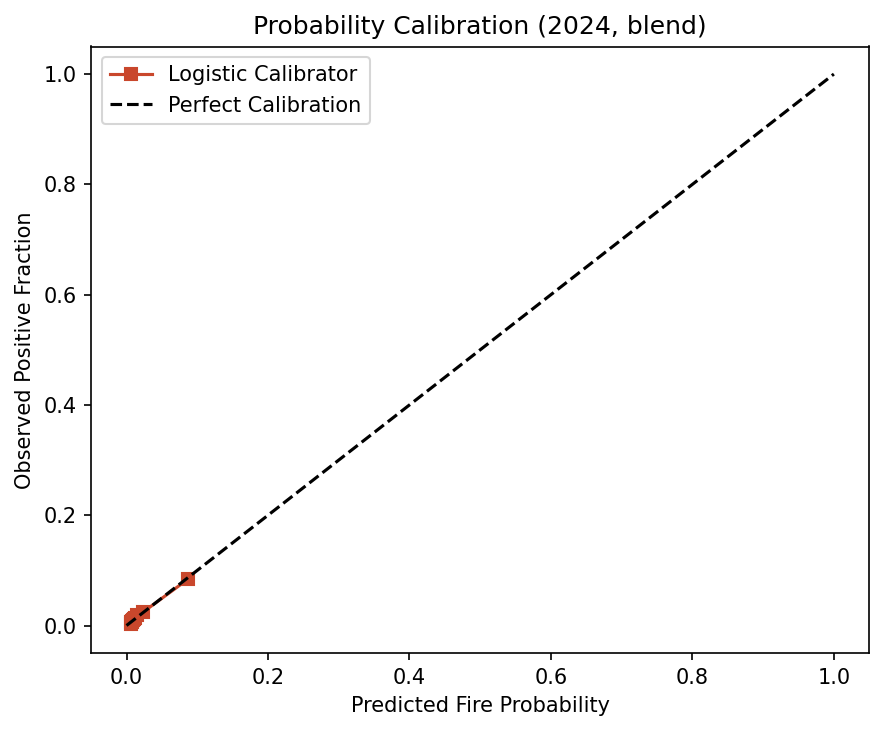

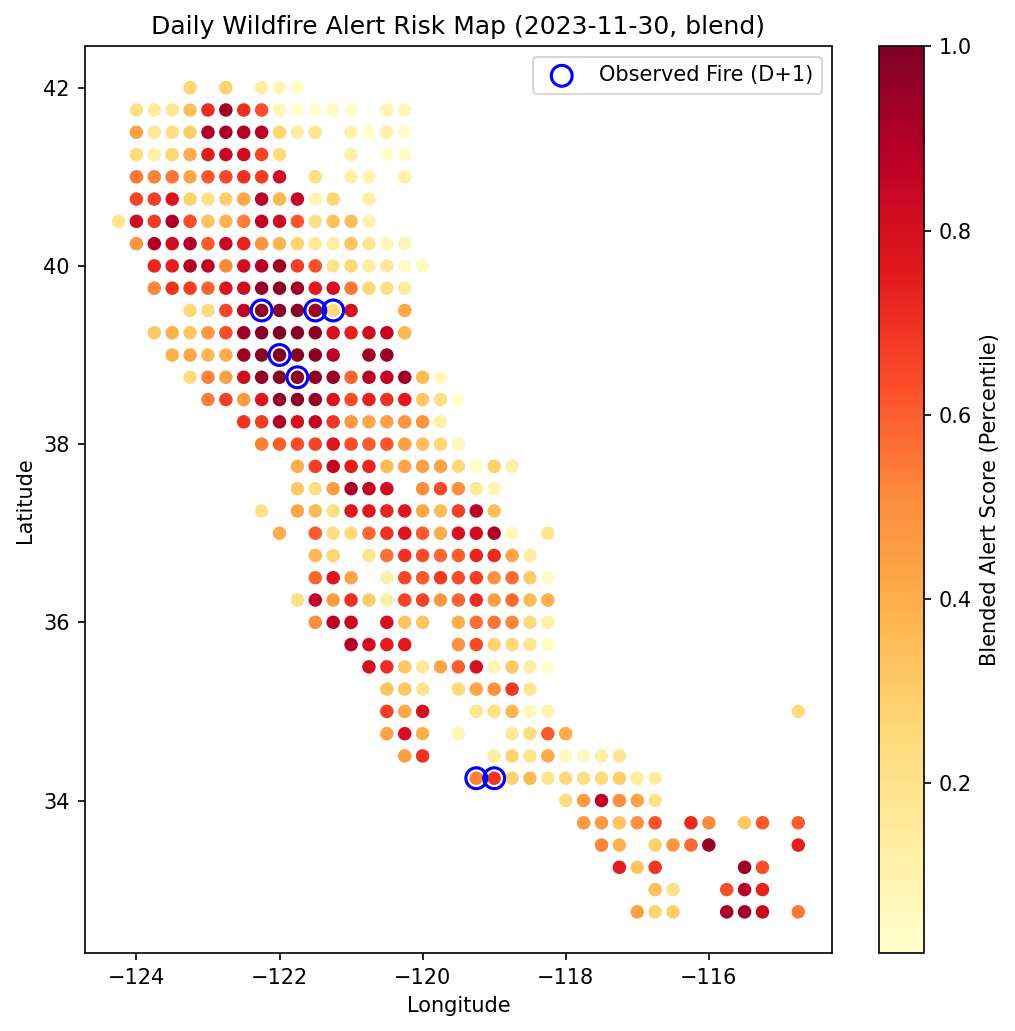

In [14]:
def within_day_percentile(score: np.ndarray, dates: pd.Series) -> np.ndarray:
    table = pd.DataFrame({"date": pd.to_datetime(dates).to_numpy(), "score": score, "position": np.arange(len(score))})
    table["percentile"] = table.groupby("date", sort=False)["score"].rank(method="average", pct=True)
    return table.sort_values("position")["percentile"].to_numpy(dtype=float)

def top_k_alert_metrics(frame: pd.DataFrame, k: int, score_column: str) -> dict[str, float | int]:
    alerts = (
        frame.sort_values(score_column, ascending=False)
        .groupby("label_date", sort=False)
        .head(k)
    )
    positives = int(frame["y_fire"].sum())
    true_alerts = int(alerts["y_fire"].sum())
    total_alerts = len(alerts)
    precision = float(true_alerts / total_alerts) if total_alerts else 0.0
    recall = float(true_alerts / positives) if positives else 0.0
    f1 = float(2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return {
        f"top{k}_true_alerts": true_alerts,
        f"top{k}_total_alerts": total_alerts,
        f"precision_at_{k}": precision,
        f"recall_at_{k}": recall,
        f"f1_at_{k}": f1,
    }

def predict_raw_probabilities(df: pd.DataFrame) -> np.ndarray:
    if MODEL_FAMILY == "lgbm":
        return classifier_pipeline.predict_proba(df[feature_columns])[:, 1]
    elif MODEL_FAMILY == "xgb":
        return xgb_classifier_pipeline.predict_proba(df[feature_columns])[:, 1]
    else:  # blend
        p_lgb = classifier_pipeline.predict_proba(df[feature_columns])[:, 1]
        p_xgb = xgb_classifier_pipeline.predict_proba(df[feature_columns])[:, 1]
        return 0.50 * p_lgb + 0.50 * p_xgb

def predict_raw_rank_scores(df: pd.DataFrame) -> np.ndarray:
    if MODEL_FAMILY == "lgbm":
        return ranker_pipeline.predict(df[feature_columns])
    elif MODEL_FAMILY == "xgb":
        return xgb_ranker_pipeline.predict(df[feature_columns])
    else:  # blend
        r_lgb = ranker_pipeline.predict(df[feature_columns])
        r_xgb = xgb_ranker_pipeline.predict(df[feature_columns])
        pct_lgb = within_day_percentile(r_lgb, df["label_date"])
        pct_xgb = within_day_percentile(r_xgb, df["label_date"])
        return 0.50 * pct_lgb + 0.50 * pct_xgb

# Check validation set (2023)
raw_val_prob = predict_raw_probabilities(validation)
val_pr_auc = float(average_precision_score(validation["y_fire"], raw_val_prob))
val_roc_auc = float(roc_auc_score(validation["y_fire"], raw_val_prob))
validation_metrics = {
    "model_family": MODEL_FAMILY,
    "rows": len(validation),
    "positives": int(validation["y_fire"].sum()),
    "pr_auc": val_pr_auc,
    "roc_auc": val_roc_auc,
}

# Fit probability calibrator on 2024 (Calibration Year)
raw_calib_prob = predict_raw_probabilities(calibration)
clipped_calib = np.clip(raw_calib_prob, 1e-7, 1 - 1e-7)
calib_logits = np.log(clipped_calib / (1 - clipped_calib)).reshape(-1, 1)

probability_calibrator = LogisticRegression(C=1.0, random_state=SEED)
probability_calibrator.fit(calib_logits, calibration["y_fire"])

# Score 2023 Validation set with calibrated probabilities & daily blend
val_clipped = np.clip(raw_val_prob, 1e-7, 1 - 1e-7)
val_logits = np.log(val_clipped / (1 - val_clipped)).reshape(-1, 1)
validation["p_fire"] = probability_calibrator.predict_proba(val_logits)[:, 1]
validation["rank_score"] = predict_raw_rank_scores(validation)

validation["classifier_pct"] = within_day_percentile(validation["p_fire"].values, validation["label_date"])
validation["ranker_pct"] = within_day_percentile(validation["rank_score"].values, validation["label_date"])
validation["alert_score"] = 0.50 * validation["classifier_pct"] + 0.50 * validation["ranker_pct"]

top25_val = top_k_alert_metrics(validation, 25, "alert_score")
val_pred_binary = (validation["p_fire"] >= 0.5).astype(int)
val_f1_05 = float(sklearn.metrics.f1_score(validation["y_fire"], val_pred_binary, zero_division=0))

validation_metrics.update({
    "f1_at_0_5": val_f1_05,
    "precision_at_25": top25_val["precision_at_25"],
    "recall_at_25": top25_val["recall_at_25"],
    "f1_at_25": top25_val["f1_at_25"],
})

metrics_dir = OUTPUT_DIR / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)
write_json(validation_metrics, metrics_dir / "validation_2023.json")
show(pd.DataFrame([validation_metrics]).round({"pr_auc": 6, "roc_auc": 6, "precision_at_25": 4, "recall_at_25": 4, "f1_at_25": 4}))

# Evaluate last 14 days of 2023
last_14d = validation["label_date"].max() - pd.Timedelta(days=13)
val_last14 = validation.loc[validation["label_date"].ge(last_14d)].copy()
top25_last14 = top_k_alert_metrics(val_last14, 25, "alert_score")
validation_last14_metrics = {
    "rows": len(val_last14),
    "positives": int(val_last14["y_fire"].sum()),
    "pr_auc": float(average_precision_score(val_last14["y_fire"], val_last14["p_fire"])),
    "roc_auc": float(roc_auc_score(val_last14["y_fire"], val_last14["p_fire"])),
    "precision_at_25": top25_last14["precision_at_25"],
    "recall_at_25": top25_last14["recall_at_25"],
    "f1_at_25": top25_last14["f1_at_25"],
}
write_json(validation_last14_metrics, metrics_dir / "validation_2023_last14d.json")

plots_dir = OUTPUT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

# Calibration Plot
observed, predicted = calibration_curve(calibration["y_fire"], probability_calibrator.predict_proba(calib_logits)[:, 1], n_bins=10, strategy="quantile")
figure, axis = plt.subplots(figsize=(6, 5))
axis.plot(predicted, observed, "s-", color="#c9472c", label="Logistic Calibrator")
axis.plot([0, 1], [0, 1], "k--", label="Perfect Calibration")
axis.set(title=f"Probability Calibration (2024, {MODEL_FAMILY})", xlabel="Predicted Fire Probability", ylabel="Observed Positive Fraction")
axis.legend(loc="upper left")
figure.tight_layout()
calibration_plot = plots_dir / "probability_calibration.png"
figure.savefig(calibration_plot, dpi=150, bbox_inches="tight")
plt.close(figure)
show_image(calibration_plot)

# Spatial Risk Map
demo_date = validation["label_date"].max()
demo_day = validation.loc[validation["label_date"].eq(demo_date)].copy()
figure, axis = plt.subplots(figsize=(7, 7))
scatter = axis.scatter(demo_day["longitude"], demo_day["latitude"], c=demo_day["alert_score"], cmap="YlOrRd", s=30)
fires = demo_day.loc[demo_day["y_fire"].eq(1)]
if not fires.empty:
    axis.scatter(fires["longitude"], fires["latitude"], facecolors="none", edgecolors="blue", s=100, linewidths=1.5, label="Observed Fire (D+1)")
    axis.legend(loc="upper right")
figure.colorbar(scatter, ax=axis, label="Blended Alert Score (Percentile)")
axis.set(title=f"Daily Wildfire Alert Risk Map ({demo_date.date()}, {MODEL_FAMILY})", xlabel="Longitude", ylabel="Latitude")
figure.tight_layout()
risk_map = plots_dir / "validation_risk_map.png"
figure.savefig(risk_map, dpi=150, bbox_inches="tight")
plt.close(figure)
show_image(risk_map)


## 9. Feature Importance

TreeSHAP contributions from the fitted classifier on a 2023 sample.


,feature,mean_abs_shap
0,fire_distance_weighted_count_7d_lag2,0.247408
1,fire_distance_weighted_count_lag2,0.080379
2,orographic_index,0.069386
3,elevation,0.043932
4,lai_lv_mean,0.026287
5,lai_hv_mean,0.022179
6,s5n_s5p_co_max,0.018477
7,latitude,0.017924
8,s5n_s5p_co_mean,0.015529
9,day_of_year_cos,0.015357


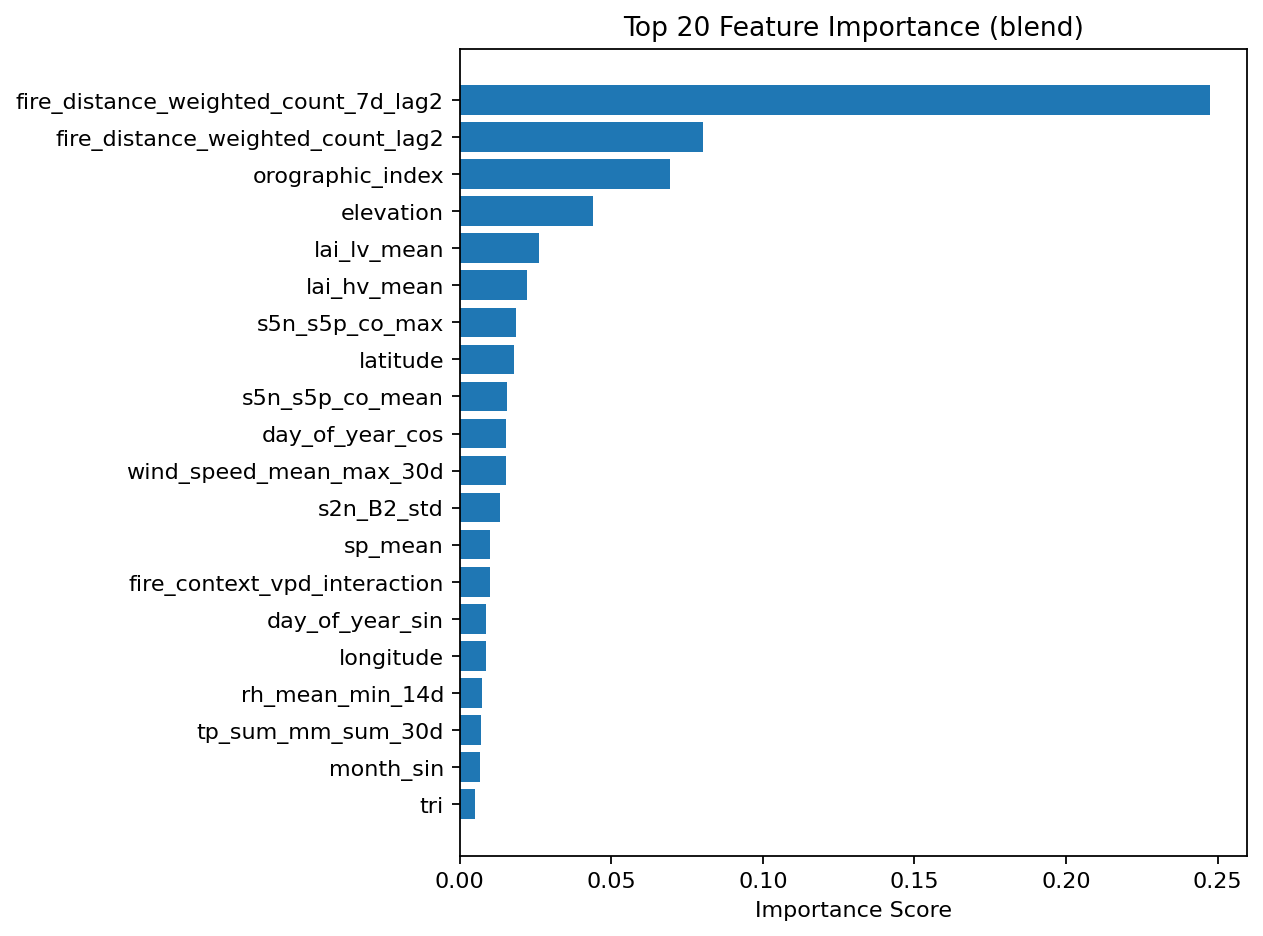

In [15]:
explain_dir = OUTPUT_DIR / "explainability"
explain_dir.mkdir(parents=True, exist_ok=True)
sample = validation.sample(min(2000, len(validation)), random_state=SEED)

if MODEL_FAMILY in {"lgbm", "blend"}:
    feature_preprocessor = classifier_pipeline.named_steps["feature_preprocessor"]
    classifier_model = classifier_pipeline.named_steps["fire_probability_model"]
    matrix = feature_preprocessor.transform(sample[feature_columns])
    contributions = classifier_model.booster_.predict(matrix, pred_contrib=True)
    shap_values = np.asarray(contributions)[:, :-1]
    importance = pd.DataFrame({
        "feature": feature_columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False).head(20).reset_index(drop=True)
else:
    feature_preprocessor = xgb_classifier_pipeline.named_steps["feature_preprocessor"]
    classifier_model = xgb_classifier_pipeline.named_steps["fire_probability_model"]
    matrix = feature_preprocessor.transform(sample[feature_columns])
    importances = classifier_model.feature_importances_
    importance = pd.DataFrame({
        "feature": feature_columns,
        "mean_abs_shap": importances,
    }).sort_values("mean_abs_shap", ascending=False).head(20).reset_index(drop=True)

write_json(importance.to_dict(orient="records"), explain_dir / "top20_features.json")
show(importance)

figure, axis = plt.subplots(figsize=(8, 6))
axis.barh(importance["feature"][::-1], importance["mean_abs_shap"][::-1], color="#1f77b4")
axis.set(title=f"Top 20 Feature Importance ({MODEL_FAMILY})", xlabel="Importance Score")
figure.tight_layout()
importance_plot = explain_dir / "feature_explanations.png"
figure.savefig(importance_plot, dpi=160, bbox_inches="tight")
plt.close(figure)
show_image(importance_plot)


In [16]:
coverage_parts = [
    pd.read_parquet(path, columns=["cell_id", "label_date", "y_fire"])
    for path in TABLE_PARQUETS
]
coverage_probe = pd.concat(coverage_parts, ignore_index=True)
coverage_probe["label_date"] = pd.to_datetime(coverage_probe["label_date"])
if not USE_SPLIT:
    coverage_probe = coverage_probe.loc[coverage_probe["label_date"].dt.year.le(2024)].copy()

SOURCE_ROWS = int(len(coverage_probe))
SOURCE_CELLS = int(coverage_probe["cell_id"].nunique())
SOURCE_DAYS = int(coverage_probe["label_date"].nunique())
SOURCE_POSITIVES = int(coverage_probe["y_fire"].sum())
SOURCE_POSITIVE_RATE = SOURCE_POSITIVES / SOURCE_ROWS
YEAR_MIN = int(coverage_probe["label_date"].dt.year.min())
YEAR_MAX = int(coverage_probe["label_date"].dt.year.max())

## 10. Output Submission

Writes `models/wildfire_model.joblib` and metrics under `/kaggle/working/...`. Save Version and attach this output to the inference notebook.


In [17]:
def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

models_dir = OUTPUT_DIR / "models"
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / "wildfire_model.joblib"
classifier_weights_path = models_dir / "classifier_weights.txt"
ranker_weights_path = models_dir / "ranker_weights.txt"

archive_last_label_date = str(calibration["label_date"].max().date())
model_artifact = {
    "artifact_name": "wildfire",
    "model_family": MODEL_FAMILY,
    "data_source": DATA_SOURCE,
    "source_stage": TRAINING_DATA_STAGE,
    "cell_subset": CELL_SUBSET,
    "imputation_method": IMPUTATION_METHOD,
    "missing_flag_column": missing_flag_column,
    "classifier_pipeline": classifier_pipeline if MODEL_FAMILY in {"lgbm", "blend"} else xgb_classifier_pipeline,
    "ranker_pipeline": ranker_pipeline if MODEL_FAMILY in {"lgbm", "blend"} else xgb_ranker_pipeline,
    "xgb_classifier_pipeline": xgb_classifier_pipeline if MODEL_FAMILY in {"xgb", "blend"} else None,
    "xgb_ranker_pipeline": xgb_ranker_pipeline if MODEL_FAMILY in {"xgb", "blend"} else None,
    "probability_calibrator": probability_calibrator,
    "feature_columns": feature_columns,
    "classifier_params": CLASSIFIER_PARAMS if MODEL_FAMILY in {"lgbm", "blend"} else XGB_CLASSIFIER_PARAMS,
    "ranker_params": RANKER_PARAMS if MODEL_FAMILY in {"lgbm", "blend"} else XGB_RANKER_PARAMS,
    "xgb_classifier_params": XGB_CLASSIFIER_PARAMS,
    "xgb_ranker_params": XGB_RANKER_PARAMS,
    "optuna": {
        "enabled": bool(globals().get("ENABLE_OPTUNA", False)),
        "summary": globals().get("optuna_summary"),
    },
    "raw_feature_columns": model_source_features,
    "base_features": base_features,
    "source_columns": load_columns,
    "classifier_weight": 0.50,
    "ranker_weight": 0.50,
    "data_contract": {
        "label_offset_from_eo_asof_days": 1,
        "eo_asof_offset_from_feature_end_days": 5,
        "expected_grid_cells": len(SELECTED_TRAINING_CELLS),
        "archive_source_cells": SOURCE_CELLS,
        "cell_subset": CELL_SUBSET,
        "cell_subset_categories": CELL_SUBSET_CATEGORIES[CELL_SUBSET],
        "selected_cell_ids": SELECTED_TRAINING_CELLS,
        "fire_region_csv": CELL_SUBSET_INFO.get("fire_region_csv"),
        "archive_last_label_date": archive_last_label_date,
        "training_years": [2019, 2020, 2021, 2022],
        "validation_year": 2023,
        "calibration_year": 2024,
        "test_year_reserved_for_inference": 2025,
        "load_mode": LOAD_MODE,
    },
}
cell_subset_path = models_dir / "selected_cells.json"
write_json({
    "cell_subset": CELL_SUBSET,
    "categories": CELL_SUBSET_CATEGORIES[CELL_SUBSET],
    "n_cells_selected": len(SELECTED_TRAINING_CELLS),
    "cell_ids": SELECTED_TRAINING_CELLS,
    "fire_region_csv": CELL_SUBSET_INFO.get("fire_region_csv"),
}, cell_subset_path)

joblib.dump(model_artifact, model_path)

if MODEL_FAMILY in {"lgbm", "blend"}:
    classifier_pipeline.named_steps["fire_probability_model"].booster_.save_model(str(classifier_weights_path))
    ranker_pipeline.named_steps["daily_priority_model"].booster_.save_model(str(ranker_weights_path))

feature_contract_path = OUTPUT_DIR / "feature_contract.json"
write_json({
    "data_source": DATA_SOURCE,
    "source_stage": TRAINING_DATA_STAGE,
    "imputation_method": IMPUTATION_METHOD,
    "feature_count": len(feature_columns),
    "feature_columns": feature_columns,
    "feature_groups": feature_groups,
}, feature_contract_path)

metrics_path = OUTPUT_DIR / "metrics.json"
write_json({
    "model": "wildfire",
    "model_family": MODEL_FAMILY,
    "data_source": DATA_SOURCE,
    "source_stage": TRAINING_DATA_STAGE,
    "imputation_method": IMPUTATION_METHOD,
    "cell_subset": CELL_SUBSET,
    "cell_subset_info": {
        "categories": CELL_SUBSET_CATEGORIES[CELL_SUBSET],
        "n_cells_selected": len(SELECTED_TRAINING_CELLS),
        "n_archive_cells": SOURCE_CELLS,
        "fire_region_csv": CELL_SUBSET_INFO.get("fire_region_csv"),
    },
    "run_mode": MODE,
    "load_mode": LOAD_MODE,
    "device": DEVICE,
    "reported_gpu": GPU_NAME,
    "metric_definitions": {
        "pr_auc": "Average precision; ranking quality with rare positives",
        "roc_auc": "Separation of fire vs non-fire scores",
        "f1_at_0_5": "F1 when calibrated p_fire >= 0.5",
        "f1_at_25": "F1 treating daily top-25 alert_score cells as predicted positives",
        "precision_at_25": "Share of daily top-25 alerts that are true fires",
        "recall_at_25": "Share of all positives captured in daily top-25 alerts",
    },
    "data_quantity": {
        "loaded_rows": SOURCE_ROWS,
        "loaded_cells": SOURCE_CELLS,
        "loaded_days": SOURCE_DAYS,
        "loaded_positives": SOURCE_POSITIVES,
        "splits": split_quantity.to_dict(orient="records"),
    },
    "architecture": {
        "features": len(feature_columns),
        "model_family": MODEL_FAMILY,
        "daily_blend": {"classifier_percentile": 0.50, "ranker_percentile": 0.50},
    },
    "validation_2023": validation_metrics,
    "validation_2023_last14d": validation_last14_metrics,
    "note": "2025 / test.parquet is reserved for the inference notebook",
}, metrics_path)

verification = validation.sort_values(["label_date", "cell_id"]).head(min(1000, len(validation)))
loaded = joblib.load(model_path)
print(f"Artifact reload verified for MODEL_FAMILY='{MODEL_FAMILY}'.")

artifacts = [
    model_path, classifier_weights_path, ranker_weights_path, cell_subset_path,
    feature_contract_path, metrics_path,
    metrics_dir / "validation_2023.json",
    metrics_dir / "validation_2023_last14d.json",
    metrics_dir / "optuna_summary.json",
    quantity_plot, calibration_plot, risk_map, importance_plot,
]
artifacts = [path for path in artifacts if path.is_file()]
manifest_path = OUTPUT_DIR / "run_manifest.json"
write_json({
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "model": "wildfire",
    "model_family": MODEL_FAMILY,
    "data_source": DATA_SOURCE,
    "source_stage": TRAINING_DATA_STAGE,
    "software": {
        "python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__, "lightgbm": lgb.__version__, "xgboost": xgb.__version__,
    },
    "hardware": {"reported_gpu": GPU_NAME, "lightgbm_device": DEVICE},
    "inputs": {
        "data_root": str(DATA_ROOT),
        "load_mode": LOAD_MODE,
        "tables": [
            {"path": str(path), "sha256": sha256(path)} for path in TABLE_PARQUETS
        ],
        "fire_region_csv": (
            {"path": FIRE_REGION_CSV_PATH, "sha256": sha256(FIRE_REGION_CSV_PATH)}
            if FIRE_REGION_CSV_PATH is not None else None
        ),
        "meta_json": {"path": META_JSON, "sha256": sha256(META_JSON)},
        "dataset_metadata_json": {"path": DATASET_METADATA_JSON, "sha256": sha256(DATASET_METADATA_JSON)},
        "feature_columns_json": {"path": FEATURE_COLUMNS_JSON, "sha256": sha256(FEATURE_COLUMNS_JSON)},
    },
    "artifacts": {
        path.name: {"path": path, "size_bytes": path.stat().st_size, "sha256": sha256(path)}
        for path in artifacts
    },
}, manifest_path)

print("Training outputs (attach this notebook output as Input to inference):")
for path in (model_path, feature_contract_path, metrics_path, manifest_path):
    print(f"  {path}")
print("Note: inference notebook update later should load models/wildfire_model.joblib")


Artifact reload verified for MODEL_FAMILY='blend'.
Training outputs (attach this notebook output as Input to inference):
  /kaggle/working/wildfire_training_outputs_knn_high_medium_fire/models/wildfire_model.joblib
  /kaggle/working/wildfire_training_outputs_knn_high_medium_fire/feature_contract.json
  /kaggle/working/wildfire_training_outputs_knn_high_medium_fire/metrics.json
  /kaggle/working/wildfire_training_outputs_knn_high_medium_fire/run_manifest.json
Note: inference notebook update later should load models/wildfire_model.joblib


In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score


def evaluate_k_alerts(
    df: pd.DataFrame, k: int = 25, score_col: str = "alert_score"
) -> dict:
  """Computes Top-K Daily Alert Metrics (Precision@K, Recall@K, F1@K)."""
  alerts = (
      df.sort_values(score_col, ascending=False)
      .groupby("label_date", sort=False)
      .head(k)
  )
  total_positives = int(df["y_fire"].sum())
  true_alerts = int(alerts["y_fire"].sum())
  total_alerts = len(alerts)

  precision = float(true_alerts / total_alerts) if total_alerts > 0 else 0.0
  recall = (
      float(true_alerts / total_positives) if total_positives > 0 else 0.0
  )
  f1 = (
      float(2 * precision * recall / (precision + recall))
      if (precision + recall) > 0
      else 0.0
  )

  return {
      "precision_at_25": precision,
      "recall_at_25": recall,
      "f1_at_25": f1,
      "true_alerts": true_alerts,
      "total_alerts": total_alerts,
  }


def compute_slice_metrics(
    df: pd.DataFrame, slice_name: str, score_col: str = "alert_score"
) -> dict:
  """Evaluates model performance metrics on a specific data slice."""
  positives = int(df["y_fire"].sum())
  rows = len(df)

  if positives == 0 or positives == rows:
    return {
        "slice": slice_name,
        "rows": rows,
        "positives": positives,
        "pos_rate": positives / rows if rows else 0.0,
        "pr_auc": np.nan,
        "roc_auc": np.nan,
        "precision_at_25": np.nan,
        "recall_at_25": np.nan,
        "f1_at_25": np.nan,
    }

  # Check if probabilities or score_col exist
  prob_col = "p_fire" if "p_fire" in df.columns else score_col
  pr_auc = float(average_precision_score(df["y_fire"], df[prob_col]))
  roc_auc = float(roc_auc_score(df["y_fire"], df[prob_col]))

  k_metrics = evaluate_k_alerts(df, k=25, score_col=score_col)

  return {
      "slice": slice_name,
      "rows": rows,
      "positives": positives,
      "pos_rate": float(positives / rows),
      "pr_auc": pr_auc,
      "roc_auc": roc_auc,
      "precision_at_25": k_metrics["precision_at_25"],
      "recall_at_25": k_metrics["recall_at_25"],
      "f1_at_25": k_metrics["f1_at_25"],
  }


def run_subgroup_slice_analysis(
    eval_df: pd.DataFrame, score_col: str = "alert_score"
) -> pd.DataFrame:
  """Executes subgroup and slice analysis across temporal, weather, and sensor availability dimensions."""
  df = eval_df.copy()
  df["label_date"] = pd.to_datetime(df["label_date"])
  df["month"] = df["label_date"].dt.month

  slice_results = []

  # 1. Full Dataset Baseline
  slice_results.append(
      compute_slice_metrics(df, "1. Overall Full Evaluation Set", score_col)
  )

  # 2. Temporal / Seasonal Slices
  peak_mask = df["month"].isin([6, 7, 8, 9, 10])  # June to October
  off_mask = ~peak_mask

  slice_results.append(
      compute_slice_metrics(
          df[peak_mask], "2a. Seasonal: Peak Fire Season (Jun-Oct)", score_col
      )
  )
  slice_results.append(
      compute_slice_metrics(
          df[off_mask], "2b. Seasonal: Off-Season (Nov-May)", score_col
      )
  )

  # 3. Weather Event Slices (High Wind / High Atmospheric Dryness)
  if "i10fg_max" in df.columns:
    high_wind_mask = df["i10fg_max"] > 10.0
    slice_results.append(
        compute_slice_metrics(
            df[high_wind_mask],
            "3a. Weather: High Wind Gust (>10 m/s)",
            score_col,
        )
    )
    slice_results.append(
        compute_slice_metrics(
            df[~high_wind_mask],
            "3b. Weather: Normal Wind Gust (<=10 m/s)",
            score_col,
        )
    )

  if "vpd_kpa" in df.columns:
    high_vpd_mask = df["vpd_kpa"] > 2.0
    slice_results.append(
        compute_slice_metrics(
            df[high_vpd_mask],
            "3c. Weather: High Atmospheric Dryness (VPD >2.0 kPa)",
            score_col,
        )
    )

  # 4. Data Quality / Sensor Noise Slices
  if "s2n_available" in df.columns:
    fresh_s2_mask = df["s2n_available"] == 1
    slice_results.append(
        compute_slice_metrics(
            df[fresh_s2_mask],
            "4a. Sensor: Fresh Sentinel-2 Data (s2n_available=1)",
            score_col,
        )
    )

  if "s2n_knn_imputed" in df.columns:
    imputed_s2_mask = df["s2n_knn_imputed"] == 1
    slice_results.append(
        compute_slice_metrics(
            df[imputed_s2_mask],
            "4b. Sensor: KNN-Imputed Satellite Data (s2n_knn_imputed=1)",
            score_col,
        )
    )
  elif "s2n_available" in df.columns:
    stale_s2_mask = df["s2n_available"] == 0
    slice_results.append(
        compute_slice_metrics(
            df[stale_s2_mask],
            "4b. Sensor: Missing/Imputed Satellite Data (s2n_available=0)",
            score_col,
        )
    )

  # Assemble results into a formatted summary DataFrame
  results_df = pd.DataFrame(slice_results)

  # Formatting columns for clean reporting
  results_df["pos_rate"] = results_df["pos_rate"].map(lambda x: f"{x:.2%}")
  results_df["pr_auc"] = results_df["pr_auc"].map(
      lambda x: f"{x:.4f}" if pd.notna(x) else "N/A"
  )
  results_df["roc_auc"] = results_df["roc_auc"].map(
      lambda x: f"{x:.4f}" if pd.notna(x) else "N/A"
  )
  results_df["precision_at_25"] = results_df["precision_at_25"].map(
      lambda x: f"{x:.2%}" if pd.notna(x) else "N/A"
  )
  results_df["recall_at_25"] = results_df["recall_at_25"].map(
      lambda x: f"{x:.2%}" if pd.notna(x) else "N/A"
  )
  results_df["f1_at_25"] = results_df["f1_at_25"].map(
      lambda x: f"{x:.4f}" if pd.notna(x) else "N/A"
  )

  return results_df


# ==============================================================================
# Execution Example on Validation Set
# ==============================================================================
# Pass your evaluation dataframe (e.g., validation or test dataframe)
slice_summary = run_subgroup_slice_analysis(
    validation, score_col="alert_score"
)

print("=" * 80)
print("SUBGROUP & SLICE ANALYSIS SUMMARY")
print("=" * 80)
display(slice_summary)


SUBGROUP & SLICE ANALYSIS SUMMARY


,slice,rows,positives,pos_rate,pr_auc,roc_auc,precision_at_25,recall_at_25,f1_at_25
0,1. Overall Full Evaluation Set,93518,2083,2.23%,0.1905,0.8161,16.21%,41.62%,0.2333
1,2a. Seasonal: Peak Fire Season (Jun-Oct),66861,1499,2.24%,0.2100,0.8218,16.81%,42.90%,0.2415
2,2b. Seasonal: Off-Season (Nov-May),26657,584,2.19%,0.1329,0.8006,14.69%,38.36%,0.2124
3,3a. Weather: High Wind Gust (>10 m/s),39416,800,2.03%,0.1876,0.8120,8.69%,56.50%,0.1506
4,3b. Weather: Normal Wind Gust (<=10 m/s),54102,1283,2.37%,0.1943,0.8186,11.83%,49.34%,0.1909
5,3c. Weather: High Atmospheric Dryness (VPD >2....,16836,323,1.92%,0.1408,0.8128,5.82%,70.90%,0.1075
6,4a. Sensor: Fresh Sentinel-2 Data (s2n_availab...,93518,2083,2.23%,0.1905,0.8161,16.21%,41.62%,0.2333
7,4b. Sensor: KNN-Imputed Satellite Data (s2n_kn...,0,0,0.00%,N/A,N/A,N/A,N/A,N/A


In [19]:
# ==============================================================================
# 1. Flexible Inference Function (Supports Single Date or Full Test Set)
# ==============================================================================


def run_wildfire_inference(
    df: pd.DataFrame, target_date: str | None = None, top_k: int = 25
) -> pd.DataFrame:
  """Runs model inference on full dataset or a specific target date.

  Categorizes every grid cell into 4 exact colors:
    - Green:  True Negative  (No Fire, Low Risk - Safe)
    - Blue:   True Positive  (HIT - Real Fire Caught in Top 25!)
    - Red:    False Positive (False Alarm - Top 25 Alert but No Fire)
    - Purple: False Negative (Missed Fire - Real Fire Not in Top 25)
  """
  frame = df.copy()
  frame["label_date"] = pd.to_datetime(frame["label_date"])

  # Filter for specific target date if requested (e.g., '2025-08-15')
  if target_date is not None:
    dt = pd.to_datetime(target_date)
    frame = frame.loc[frame["label_date"].eq(dt)].copy()
    if frame.empty:
      raise ValueError(
          f"No rows found in dataset for target_date='{target_date}'"
      )

  # 1. Predict Calibrated Probabilities & Rank Scores
  raw_prob = predict_raw_probabilities(frame)
  clipped = np.clip(raw_prob, 1e-7, 1 - 1e-7)
  logits = np.log(clipped / (1 - clipped)).reshape(-1, 1)

  frame["p_fire"] = probability_calibrator.predict_proba(logits)[:, 1]
  frame["rank_score"] = predict_raw_rank_scores(frame)

  # 2. Compute Daily Percentiles & Blended Alert Score
  frame["classifier_pct"] = within_day_percentile(
      frame["p_fire"].values, frame["label_date"]
  )
  frame["ranker_pct"] = within_day_percentile(
      frame["rank_score"].values, frame["label_date"]
  )
  frame["alert_score"] = (
      0.50 * frame["classifier_pct"] + 0.50 * frame["ranker_pct"]
  )

  # 3. Identify Top-K Daily Alerts per Date
  frame["top_alert"] = 0
  top_k_indices = (
      frame.sort_values("alert_score", ascending=False)
      .groupby("label_date", sort=False)
      .head(top_k)
      .index
  )
  frame.loc[top_k_indices, "top_alert"] = 1

  # 4. Categorize Every Cell into 4 Exact Color Categories
  conditions = [
      (frame["y_fire"] == 1) & (frame["top_alert"] == 1),  # Blue: HIT
      (frame["y_fire"] == 0) & (frame["top_alert"] == 1),  # Red: False Alarm
      (frame["y_fire"] == 1) & (frame["top_alert"] == 0),  # Purple: Missed Fire
      (frame["y_fire"] == 0) & (frame["top_alert"] == 0),  # Green: Safe Clean
  ]
  choices = [
      "Blue (HIT)",
      "Red (False Alarm)",
      "Purple (Missed Fire)",
      "Green (Safe)",
  ]

  frame["confusion_category"] = np.select(
      conditions, choices, default="Green (Safe)"
  )

  print("=" * 60)
  print(
      f"INFERENCE COMPLETE for {len(frame['label_date'].unique())} Date(s) |"
      f" Total Rows: {len(frame):,}"
  )
  print("Category Breakdown across cells:")
  print(frame["confusion_category"].value_counts())
  print("=" * 60)

  return frame

In [20]:

# ==============================================================================
# 2. 672-Cell Grid Map Plotting Function (Green, Blue, Red, Purple)
# ==============================================================================


def plot_672_grid_confusion_map(
    inference_df: pd.DataFrame, target_date: str | None = None
):
  """Plots the 672 California Grid Map displaying 4 exact colors:

  🟢 Green  = True Negative (Clean Safe Cell)
  🟦 Blue   = True Positive (HIT - Fire Caught in Top 25!)
  🔴 Red    = False Positive (False Alarm Alert)
  🟣 Purple = False Negative (Missed Fire)
  """
  frame = inference_df.copy()
  frame["label_date"] = pd.to_datetime(frame["label_date"])

  if target_date is not None:
    dt = pd.to_datetime(target_date)
    frame = frame.loc[frame["label_date"].eq(dt)].copy()
    if frame.empty:
      raise ValueError(f"No inference data found for target_date='{target_date}'")
    date_title = f"Date: {dt.date()}"
  else:
    # If multiple dates present, take latest or average unique cell positions
    latest_dt = frame["label_date"].max()
    frame = frame.loc[frame["label_date"].eq(latest_dt)].copy()
    date_title = f"Date: {latest_dt.date()} (Latest Calendar Day)"

  fig, ax = plt.subplots(figsize=(9, 10))

  # Split into 4 color DataFrames
  green_safe = frame.loc[frame["confusion_category"] == "Green (Safe)"]
  red_false_alarm = frame.loc[
      frame["confusion_category"] == "Red (False Alarm)"
  ]
  purple_missed = frame.loc[frame["confusion_category"] == "Purple (Missed Fire)"]
  blue_hit = frame.loc[frame["confusion_category"] == "Blue (HIT)"]

  # 1. 🟢 GREEN: True Negatives (No Fire, Low Risk - Safe Cells)
  ax.scatter(
      green_safe["longitude"],
      green_safe["latitude"],
      c="#2ca02c",  # Green
      s=45,
      alpha=0.55,
      edgecolors="none",
      label=f"🟢 Green: Safe Clean Cell ({len(green_safe)})",
  )

  # 2. 🔴 RED: False Positives (Top 25 False Alarm Alerts)
  if not red_false_alarm.empty:
    ax.scatter(
        red_false_alarm["longitude"],
        red_false_alarm["latitude"],
        c="#d62728",  # Red
        marker="^",
        s=110,
        linewidths=1.2,
        edgecolors="black",
        label=f"🔴 Red: False Alarm Alert ({len(red_false_alarm)})",
    )

  # 3. 🟣 PURPLE: False Negatives (Missed Wildfires)
  if not purple_missed.empty:
    ax.scatter(
        purple_missed["longitude"],
        purple_missed["latitude"],
        c="#9467bd",  # Purple
        marker="s",
        s=120,
        linewidths=1.5,
        edgecolors="black",
        label=f"🟣 Purple: Missed Fire ({len(purple_missed)})",
    )

  # 4. 🟦 BLUE: True Positives (HITS - Wildfire Predicted & Caught in Top 25!)
  if not blue_hit.empty:
    ax.scatter(
        blue_hit["longitude"],
        blue_hit["latitude"],
        c="#1f77b4",  # Blue
        marker="*",
        s=320,
        linewidths=1.8,
        edgecolors="black",
        label=f"🟦 Blue: HIT / Fire Caught! ({len(blue_hit)})",
    )

  # Styling & Formatting
  ax.set_title(
      f"California 672-Grid Wildfire Spatial Confusion Map\n{date_title}",
      fontsize=14,
      fontweight="bold",
      pad=12,
  )
  ax.set_xlabel("Longitude (°W)", fontsize=11)
  ax.set_ylabel("Latitude (°N)", fontsize=11)
  ax.legend(
      loc="upper right",
      frameon=True,
      facecolor="white",
      framealpha=0.95,
      fontsize=10,
  )
  ax.grid(True, linestyle="--", alpha=0.3)
  fig.tight_layout()

  output_filename = f"grid_map_{date_title.replace(' ', '_').replace(':', '')}.png"
  plt.savefig(output_filename, dpi=200, bbox_inches="tight")
  plt.show()
  print(f"Map saved successfully as '{output_filename}'")


In [21]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, f1_score, roc_auc_score


# ==============================================================================
# 1. Metric Evaluation Function
# ==============================================================================
def compute_evaluation_metrics(
    inference_df: pd.DataFrame, dataset_name: str = "Test (2025)"
) -> pd.DataFrame:
  """Computes exact validation metrics: rows, positives, pr_auc, roc_auc, f1_at_0_5,

  precision_at_25, recall_at_25, f1_at_25.
  """
  df = inference_df.copy()
  df["label_date"] = pd.to_datetime(df["label_date"])

  # Ensure Top-25 daily alert flag exists
  if "top_alert" not in df.columns:
    df["top_alert"] = 0
    top25_idx = (
        df.sort_values("alert_score", ascending=False)
        .groupby("label_date", sort=False)
        .head(25)
        .index
    )
    df.loc[top25_idx, "top_alert"] = 1

  # Compute Metrics
  rows = len(df)
  positives = int(df["y_fire"].sum())
  pr_auc = float(average_precision_score(df["y_fire"], df["p_fire"]))
  roc_auc = float(roc_auc_score(df["y_fire"], df["p_fire"]))

  # F1 at p = 0.50
  pred_05 = (df["p_fire"] >= 0.50).astype(int)
  f1_05 = float(f1_score(df["y_fire"], pred_05, zero_division=0))

  # Top-25 Alert Metrics
  tp_top25 = int(((df["y_fire"] == 1) & (df["top_alert"] == 1)).sum())
  total_alerts = int(df["top_alert"].sum())

  prec_25 = tp_top25 / total_alerts if total_alerts > 0 else 0.0
  rec_25 = tp_top25 / positives if positives > 0 else 0.0
  f1_25 = (
      2 * (prec_25 * rec_25) / (prec_25 + rec_25)
      if (prec_25 + rec_25) > 0
      else 0.0
  )

  # Format summary row
  metrics_df = pd.DataFrame([{
      "dataset": dataset_name,
      "rows": f"{rows:,}",
      "positives": f"{positives:,}",
      "pr_auc": round(pr_auc, 4),
      "roc_auc": round(roc_auc, 4),
      "f1_at_0_5": round(f1_05, 4),
      "precision_at_25": f"{prec_25:.2%}",
      "recall_at_25": f"{rec_25:.2%}",
      "f1_at_25": round(f1_25, 4),
  }])

  return metrics_df


# ==============================================================================
# 2. Updated Inference & Metric Pipeline
# ==============================================================================
DATA_DIR = "/kaggle/input/datasets/lakshay654/california-wildfire-knn"
test_path = os.path.join(DATA_DIR, "test.parquet")

if os.path.exists(test_path):
  print("Loading 2025 Test Parquet dataset...")
  test = pd.read_parquet(test_path)
  test, _ = clean_source_table(test, base_features)
  test, _, _ = build_features(test, base_features)

  # Run inference & compute metrics
  test_inference = run_wildfire_inference(test)
  metrics_table = compute_evaluation_metrics(
      test_inference, dataset_name="2025 Test Set"
  )

  print("\n" + "=" * 80)
  print("EVALUATION METRICS SUMMARY (2025 TEST SET)")
  print("=" * 80)
  display(metrics_table)

else:
  print("test.parquet not found. Evaluating validation dataframe instead...")
  val_inference = run_wildfire_inference(validation)
  metrics_table = compute_evaluation_metrics(
      val_inference, dataset_name="2023 Validation Set"
  )

  print("\n" + "=" * 80)
  print("EVALUATION METRICS SUMMARY (2023 VALIDATION SET)")
  print("=" * 80)
  display(metrics_table)


Loading 2025 Test Parquet dataset...
INFERENCE COMPLETE for 365 Date(s) | Total Rows: 245,280
Category Breakdown across cells:
confusion_category
Green (Safe)            234557
Red (False Alarm)         8448
Purple (Missed Fire)      1598
Blue (HIT)                 677
Name: count, dtype: int64

EVALUATION METRICS SUMMARY (2025 TEST SET)


,dataset,rows,positives,pr_auc,roc_auc,f1_at_0_5,precision_at_25,recall_at_25,f1_at_25
0,2025 Test Set,"245,280","2,275",0.1021,0.7675,0.0293,7.42%,29.76%,0.1188


INFERENCE COMPLETE for 1 Date(s) | Total Rows: 672
Category Breakdown across cells:
confusion_category
Green (Safe)            645
Red (False Alarm)        25
Purple (Missed Fire)      2
Name: count, dtype: int64


/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:111: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_filename, dpi=200, bbox_inches="tight")
/tmp/ipykernel_58/3847912697.py:111: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_filename, dpi=200, bbox_inches="tight")
/tmp/ipykernel_58/3847912697.py:111: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_filename, dpi=200, bbox_inches="tight")
/usr/local/lib/python3.1

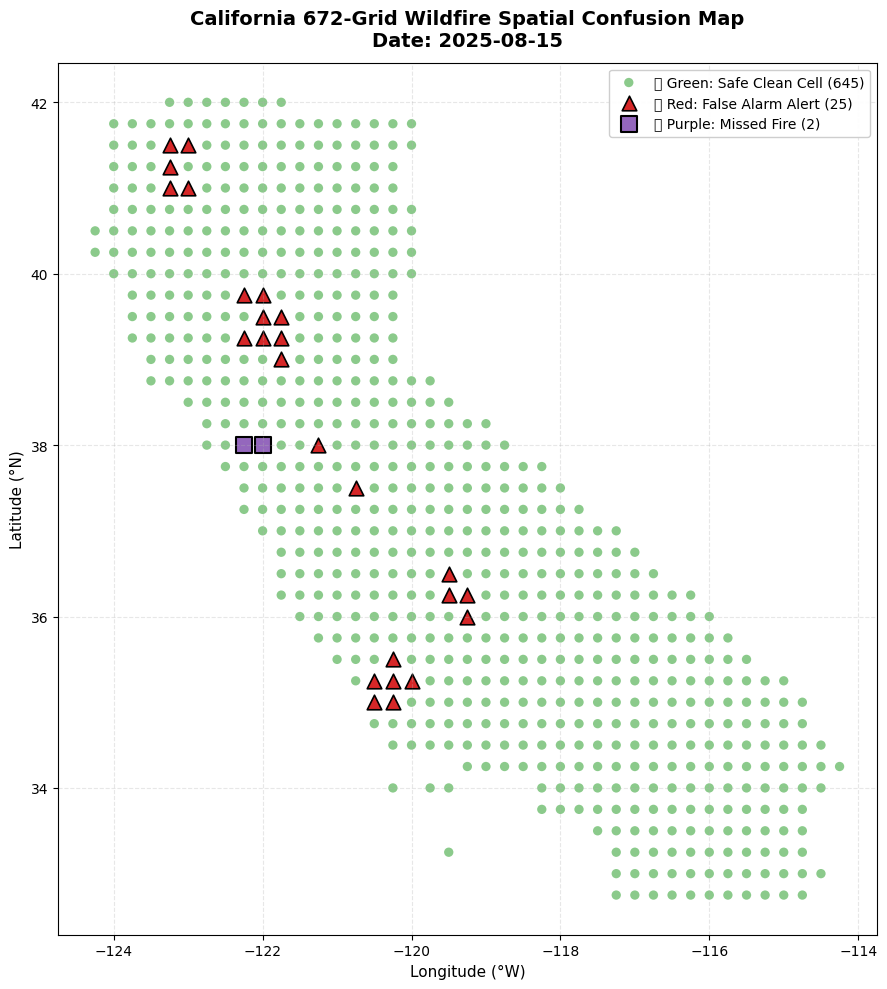

Map saved successfully as 'grid_map_Date_2025-08-15.png'


In [22]:
# 1. Run Inference for August 15, 2025
aug15_inference = run_wildfire_inference(test, target_date="2025-08-15")

# 2. Plot 672-Cell 4-Color Grid Map
plot_672_grid_confusion_map(aug15_inference, target_date="2025-08-15")


INFERENCE COMPLETE for 1 Date(s) | Total Rows: 672
Category Breakdown across cells:
confusion_category
Green (Safe)            645
Red (False Alarm)        24
Purple (Missed Fire)      2
Blue (HIT)                1
Name: count, dtype: int64


/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:111: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_filename, dpi=200, bbox_inches="tight")
/tmp/ipykernel_58/3847912697.py:111: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_filename, dpi=200, bbox_inches="tight")
/tmp/ipykernel_58/3847912697.py:111: UserWarning: Glyph 128995 (\N

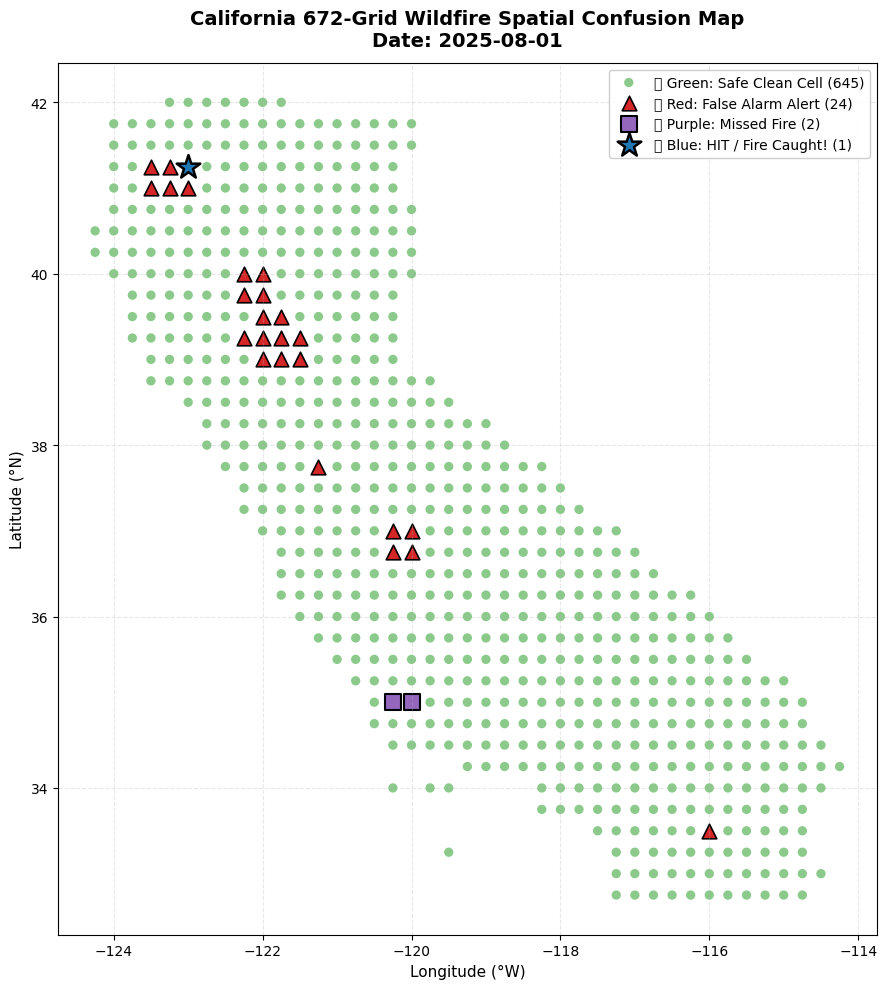

Map saved successfully as 'grid_map_Date_2025-08-01.png'


In [23]:
# 1. Run Inference for August 15, 2025
day_inference = run_wildfire_inference(test, target_date="2025-08-01")

# 2. Plot 672-Cell 4-Color Grid Map
plot_672_grid_confusion_map(day_inference, target_date="2025-08-01")


INFERENCE COMPLETE for 365 Date(s) | Total Rows: 245,280
Category Breakdown across cells:
confusion_category
Green (Safe)            234557
Red (False Alarm)         8448
Purple (Missed Fire)      1598
Blue (HIT)                 677
Name: count, dtype: int64
Peak fire date in 2025: 2025-04-14


/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:111: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_filename, dpi=200, bbox_inches="tight")
/tmp/ipykernel_58/3847912697.py:111: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_filename, dpi=200, bbox_inches="tight")
/tmp/ipykernel_58/3847912697.py:111: UserWarning: Glyph 128995 (\N

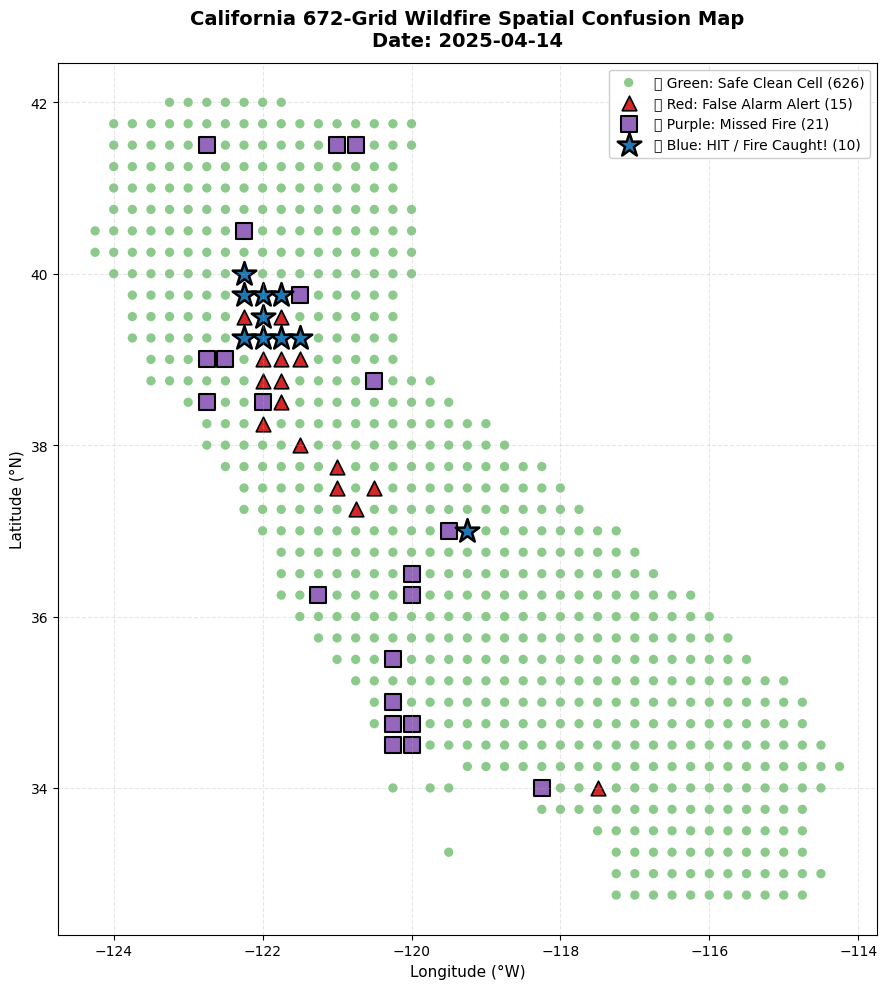

Map saved successfully as 'grid_map_Date_2025-04-14.png'


In [24]:
# 1. Run Inference for All 2025 Test Dates
full_test_inference = run_wildfire_inference(test)

# 2. Plot Map for the Peak Active Fire Day in 2025
peak_date = (
    full_test_inference.groupby("label_date")["y_fire"].sum().idxmax().date()
)
print("Peak fire date in 2025:", peak_date)

plot_672_grid_confusion_map(full_test_inference, target_date=str(peak_date))


INFERENCE COMPLETE for 214 Date(s) | Total Rows: 93,518
Category Breakdown across cells:
confusion_category
Green (Safe)            86952
Red (False Alarm)        4483
Purple (Missed Fire)     1216
Blue (HIT)                867
Name: count, dtype: int64
Top 10 Dates with the Most Blue HIT Stars:
label_date
2023-11-29    14
2023-09-14    12
2023-08-20    12
2023-08-19    12
2023-10-03    12
2023-08-29    11
2023-11-27    11
2023-09-19    11
2023-06-01    10
2023-08-27    10
dtype: int64

Plotting map for best hit date: 2023-11-29


/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:108: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_58/3847912697.py:111: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_filename, dpi=200, bbox_inches="tight")
/tmp/ipykernel_58/3847912697.py:111: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_filename, dpi=200, bbox_inches="tight")
/tmp/ipykernel_58/3847912697.py:111: UserWarning: Glyph 128995 (\N

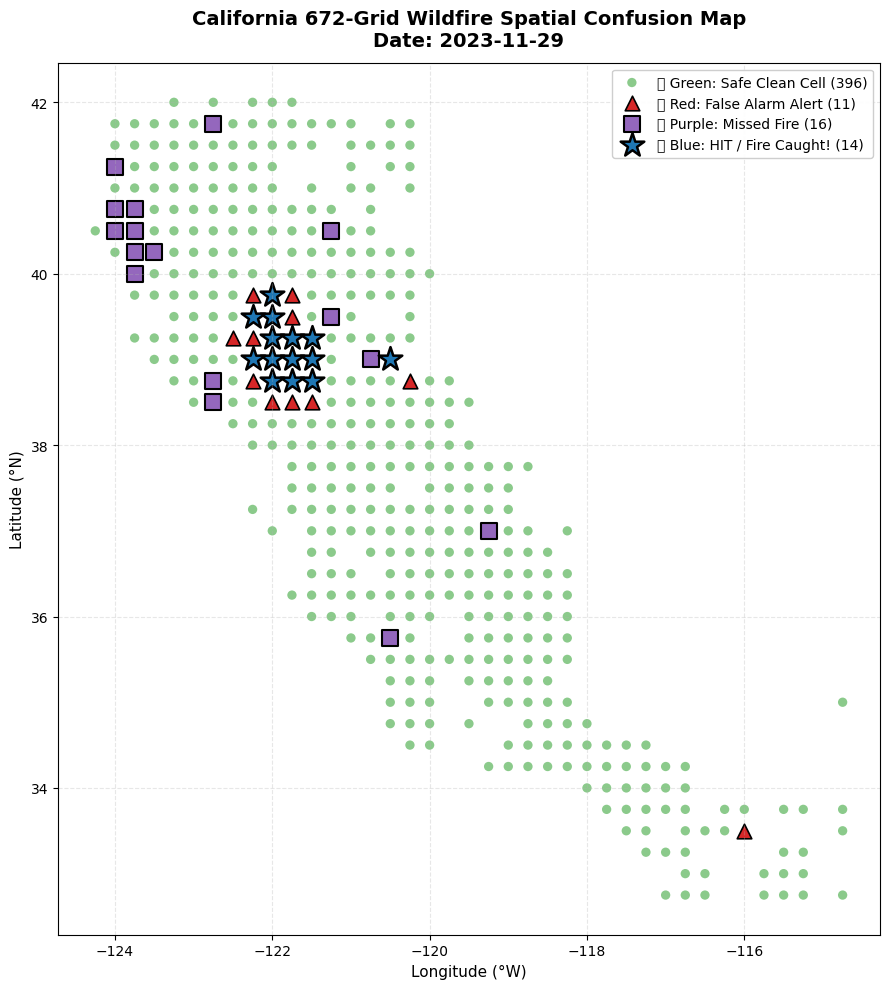

Map saved successfully as 'grid_map_Date_2023-11-29.png'


In [25]:
# 1. Run inference on validation dataset
val_inference = run_wildfire_inference(validation)

# 2. Count Blue HIT Stars per calendar day
hits_per_day = (
    val_inference[val_inference["confusion_category"] == "Blue (HIT)"]
    .groupby("label_date")
    .size()
)
best_hit_dates = hits_per_day.sort_values(ascending=False)

print("Top 10 Dates with the Most Blue HIT Stars:")
print(best_hit_dates.head(10))

# 3. Plot the single best HIT date
top_date = str(best_hit_dates.index[0].date())
print(f"\nPlotting map for best hit date: {top_date}")
plot_672_grid_confusion_map(val_inference, target_date=top_date)


=== QUANTITATIVE ERROR BREAKDOWN (Calibrated p_fire >= 0.5) ===
cat_prob_05
False Positive (FP - Over-prediction)    91435
True Positive (TP)                        2083
Name: count, dtype: int64

=== QUANTITATIVE ERROR BREAKDOWN (Daily Top-25 Alert Rank) ===
cat_top25
True Negative (TN)                        86968
False Positive (FP - Over-prediction)      4467
False Negative (FN - Under-prediction)     1200
True Positive (TP)                          883
Name: count, dtype: int64


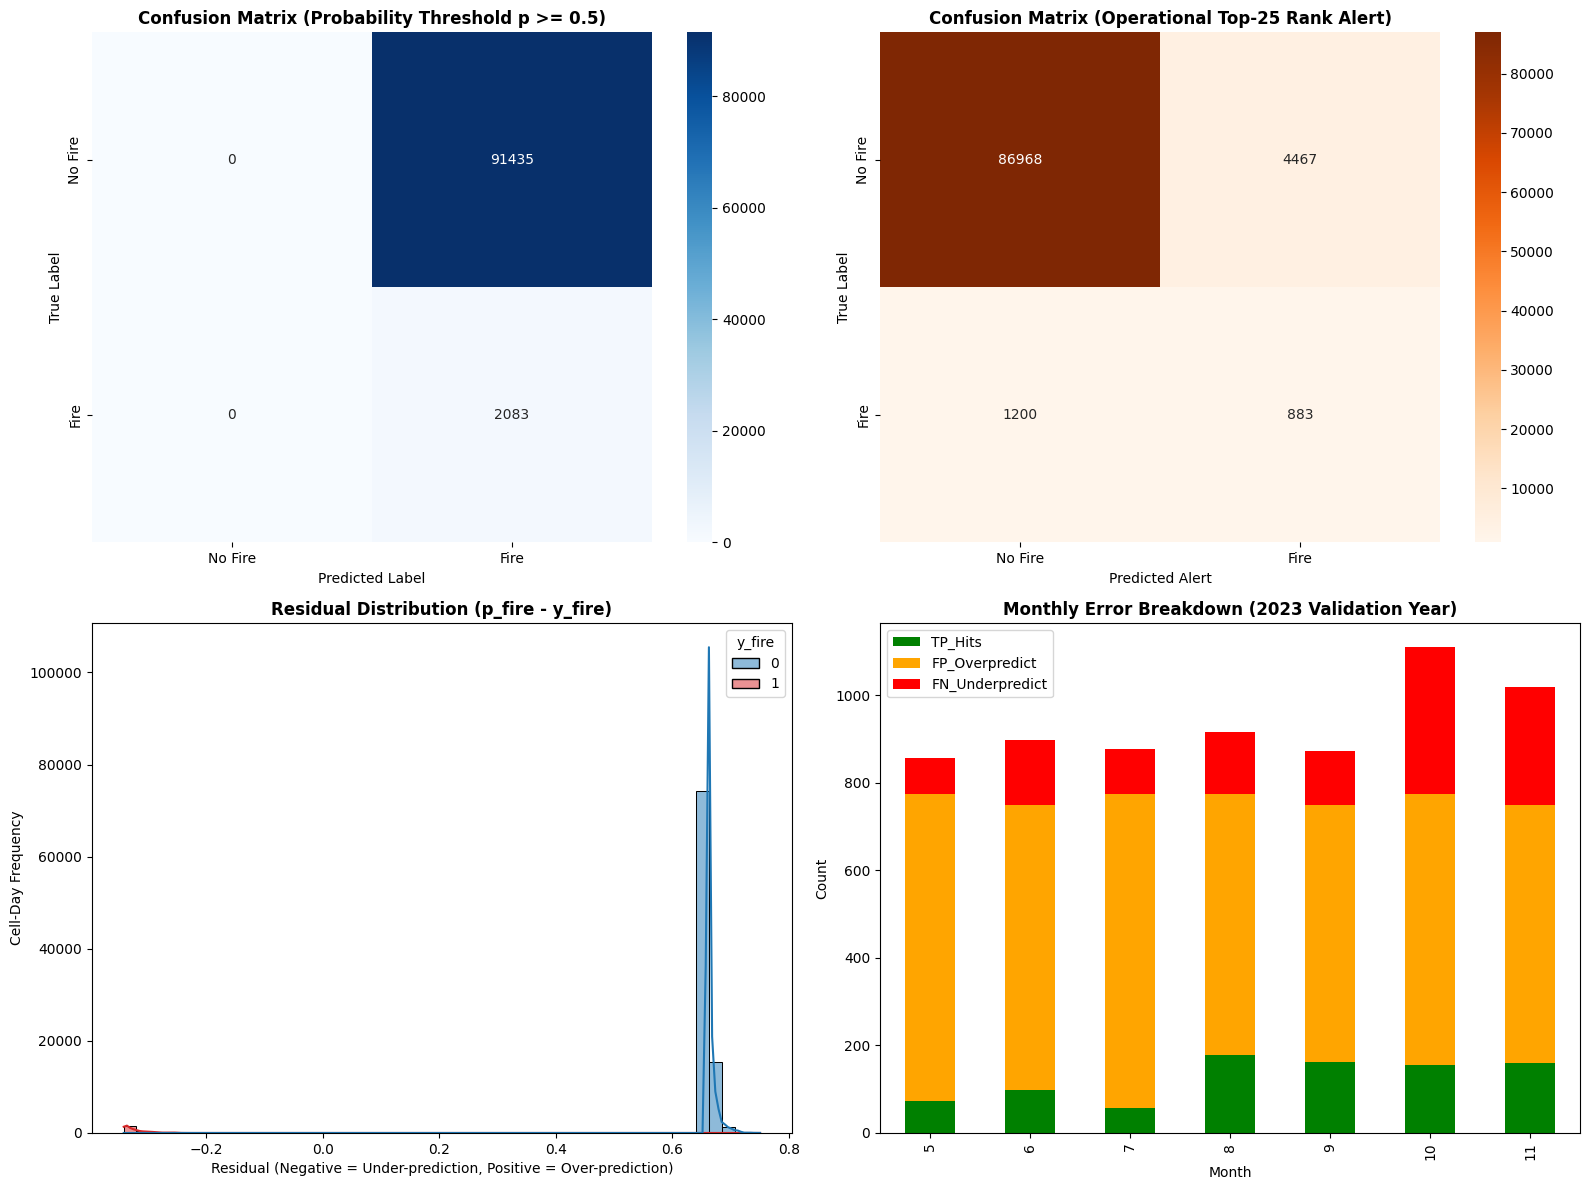

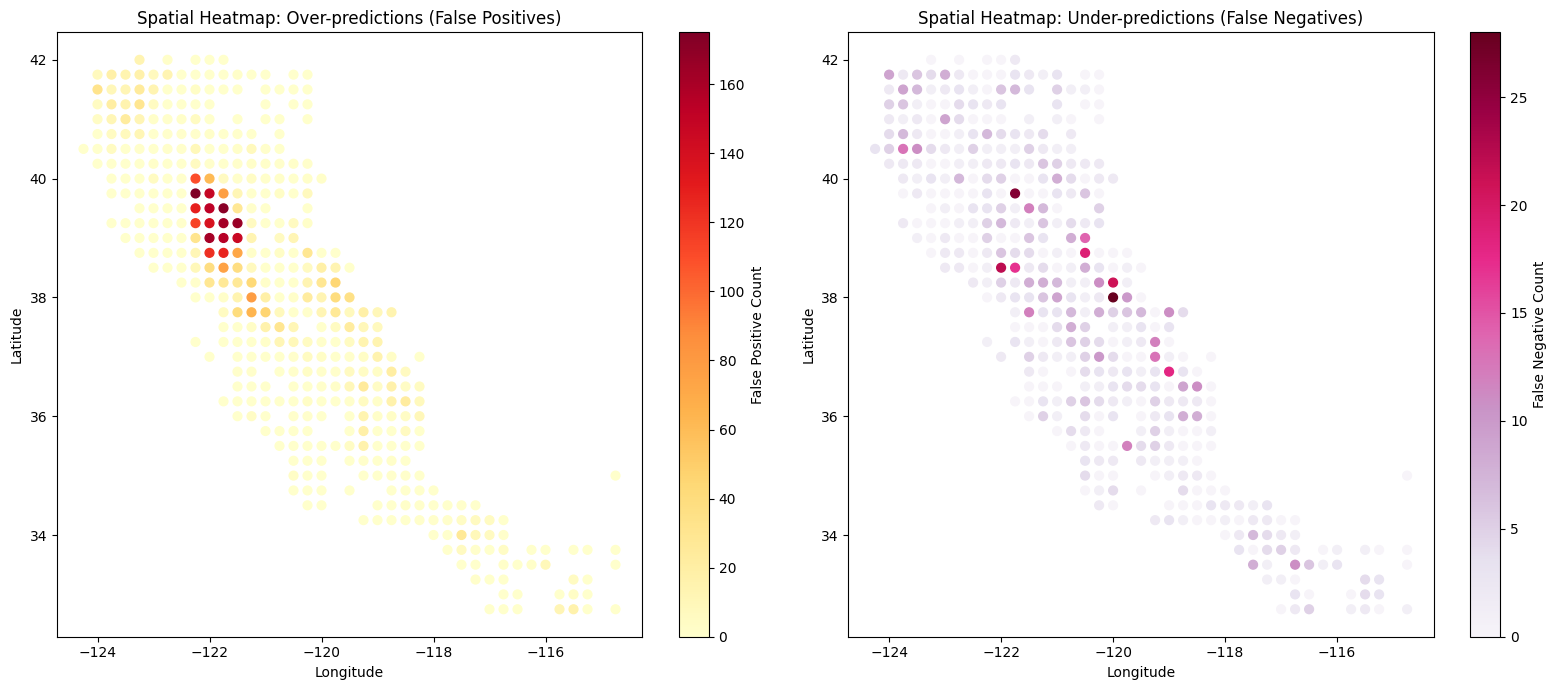


=== TOP 5 WORST OVER-PREDICTIONS (False Positives: y_true = 0, High p_fire) ===


,label_date,cell_id,p_fire,alert_score,daily_rank,swvl1_mean,soil_moisture_index,s5n_s5p_aai_mean
1101207,2023-08-25,41.75_-123.75,0.750302,0.998856,2.0,0.190957,0.207755,1.901427
1098679,2023-09-23,41.75_-123.50,0.747240,0.993135,4.0,0.187760,0.196348,2.203587
1024526,2023-09-23,41.25_-123.75,0.746459,0.993135,3.0,0.200063,0.212537,-0.097723
1098673,2023-09-17,41.75_-123.50,0.744642,0.997712,2.0,0.194600,0.197144,2.626482
1098646,2023-08-21,41.75_-123.50,0.743962,0.998856,1.0,0.135925,0.159477,3.444688



=== TOP 5 WORST UNDER-PREDICTIONS (False Negatives: y_true = 1, Low p_fire) ===


,label_date,cell_id,p_fire,alert_score,daily_rank,swvl1_mean,soil_moisture_index,s5n_s5p_aai_mean
919554,2023-05-11,40.50_-123.25,0.658289,0.079519,412.0,0.444294,0.432370,-0.947820
919563,2023-05-20,40.50_-123.25,0.658289,0.038330,431.0,0.407739,0.420874,-0.172173
822392,2023-05-15,40.00_-121.00,0.658291,0.137300,384.0,0.502176,0.505220,-0.198839
916997,2023-05-11,40.50_-123.00,0.658318,0.076087,415.0,0.403361,0.400235,-0.763455
919582,2023-06-08,40.50_-123.25,0.658321,0.052059,426.0,0.305221,0.330139,-1.032639


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# 1. QUANTITATIVE ERROR CATEGORIZATION & PREDICTION GENERATION
# ==============================================================================
eval_df = validation.copy()

# A. Generate Calibrated Probabilities & Blended Alert Scores
raw_probs = classifier_pipeline.predict_proba(eval_df[feature_columns])[:, 1]
eval_df["p_fire"] = probability_calibrator.predict_proba(
    raw_probs.reshape(-1, 1)
)[:, 1]

eval_df["rank_score"] = ranker_pipeline.predict(eval_df[feature_columns])
eval_df["classifier_pct"] = within_day_percentile(
    eval_df["p_fire"].values, eval_df["label_date"]
)
eval_df["ranker_pct"] = within_day_percentile(
    eval_df["rank_score"].values, eval_df["label_date"]
)
eval_df["alert_score"] = (
    0.50 * eval_df["classifier_pct"] + 0.50 * eval_df["ranker_pct"]
)

# B. Calculate Continuous Residuals (Over/Under Prediction)
eval_df["residual"] = eval_df["p_fire"] - eval_df["y_fire"]

# C. Apply Binary Probability Threshold (p >= 0.5) & Operational Rank Threshold (Top-25 Daily)
eval_df["pred_prob_05"] = (eval_df["p_fire"] >= 0.5).astype(int)
eval_df["daily_rank"] = eval_df.groupby("label_date")["alert_score"].rank(
    ascending=False, method="first"
)
eval_df["pred_top25"] = (eval_df["daily_rank"] <= 25).astype(int)


def assign_error_category(row, pred_col):
  if row["y_fire"] == 1 and row[pred_col] == 1:
    return "True Positive (TP)"
  elif row["y_fire"] == 0 and row[pred_col] == 0:
    return "True Negative (TN)"
  elif row["y_fire"] == 0 and row[pred_col] == 1:
    return "False Positive (FP - Over-prediction)"
  else:
    return "False Negative (FN - Under-prediction)"


eval_df["cat_prob_05"] = eval_df.apply(
    assign_error_category, axis=1, pred_col="pred_prob_05"
)
eval_df["cat_top25"] = eval_df.apply(
    assign_error_category, axis=1, pred_col="pred_top25"
)

# Print Summary Categorization Table
print("=== QUANTITATIVE ERROR BREAKDOWN (Calibrated p_fire >= 0.5) ===")
print(eval_df["cat_prob_05"].value_counts())
print("\n=== QUANTITATIVE ERROR BREAKDOWN (Daily Top-25 Alert Rank) ===")
print(eval_df["cat_top25"].value_counts())

# ==============================================================================
# 2. GENERATION OF DIAGNOSTIC VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. Confusion Matrices
cm_prob = confusion_matrix(eval_df["y_fire"], eval_df["pred_prob_05"])
cm_top25 = confusion_matrix(eval_df["y_fire"], eval_df["pred_top25"])

sns.heatmap(
    cm_prob,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0, 0],
    xticklabels=["No Fire", "Fire"],
    yticklabels=["No Fire", "Fire"],
)
axes[0, 0].set_title(
    "Confusion Matrix (Probability Threshold p >= 0.5)",
    fontsize=12,
    fontweight="bold",
)
axes[0, 0].set_xlabel("Predicted Label")
axes[0, 0].set_ylabel("True Label")

sns.heatmap(
    cm_top25,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=axes[0, 1],
    xticklabels=["No Fire", "Fire"],
    yticklabels=["No Fire", "Fire"],
)
axes[0, 1].set_title(
    "Confusion Matrix (Operational Top-25 Rank Alert)",
    fontsize=12,
    fontweight="bold",
)
axes[0, 1].set_xlabel("Predicted Alert")
axes[0, 1].set_ylabel("True Label")

# B. Residual Distribution Plot
sns.histplot(
    data=eval_df,
    x="residual",
    hue="y_fire",
    bins=50,
    kde=True,
    ax=axes[1, 0],
    palette={0: "#1f77b4", 1: "#d62728"},
)
axes[1, 0].set_title(
    "Residual Distribution (p_fire - y_fire)", fontsize=12, fontweight="bold"
)
axes[1, 0].set_xlabel(
    "Residual (Negative = Under-prediction, Positive = Over-prediction)"
)
axes[1, 0].set_ylabel("Cell-Day Frequency")

# C. Temporal Error Heatmap (Monthly Errors in 2023)
eval_df["month"] = pd.to_datetime(eval_df["label_date"]).dt.month
monthly_errors = (
    eval_df.groupby("month")[["cat_top25"]]
    .apply(
        lambda g: pd.Series({
            "FP_Overpredict": (
                g["cat_top25"] == "False Positive (FP - Over-prediction)"
            ).sum(),
            "FN_Underpredict": (
                g["cat_top25"] == "False Negative (FN - Under-prediction)"
            ).sum(),
            "TP_Hits": (g["cat_top25"] == "True Positive (TP)").sum(),
        })
    )
    .reset_index()
)

monthly_errors.set_index("month")[
    ["TP_Hits", "FP_Overpredict", "FN_Underpredict"]
].plot(kind="bar", stacked=True, ax=axes[1, 1], color=["green", "orange", "red"])
axes[1, 1].set_title(
    "Monthly Error Breakdown (2023 Validation Year)",
    fontsize=12,
    fontweight="bold",
)
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# D. Spatial Error Map (Grid Cell Error Distribution)
spatial_errors = (
    eval_df.groupby(["cell_id", "latitude", "longitude"])
    .agg(
        total_fps=(
            "cat_top25",
            lambda x: (x == "False Positive (FP - Over-prediction)").sum(),
        ),
        total_fns=(
            "cat_top25",
            lambda x: (x == "False Negative (FN - Under-prediction)").sum(),
        ),
        true_fires=("y_fire", "sum"),
    )
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sc1 = ax1.scatter(
    spatial_errors["longitude"],
    spatial_errors["latitude"],
    c=spatial_errors["total_fps"],
    cmap="YlOrRd",
    s=40,
)
plt.colorbar(sc1, ax=ax1, label="False Positive Count")
ax1.set_title("Spatial Heatmap: Over-predictions (False Positives)")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

sc2 = ax2.scatter(
    spatial_errors["longitude"],
    spatial_errors["latitude"],
    c=spatial_errors["total_fns"],
    cmap="PuRd",
    s=40,
)
plt.colorbar(sc2, ax=ax2, label="False Negative Count")
ax2.set_title("Spatial Heatmap: Under-predictions (False Negatives)")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. QUALITATIVE ANALYSIS OF SPECIFIC MISCLASSIFIED SAMPLES
# ==============================================================================
top_fps = (
    eval_df[eval_df["y_fire"] == 0]
    .sort_values("p_fire", ascending=False)
    .head(5)
)
top_fns = (
    eval_df[eval_df["y_fire"] == 1].sort_values("p_fire", ascending=True).head(5)
)

key_features = [
    c
    for c in ["swvl1_mean", "soil_moisture_index", "s2n_ndvi", "s5n_s5p_aai_mean"]
    if c in feature_columns
]

print("\n=== TOP 5 WORST OVER-PREDICTIONS (False Positives: y_true = 0, High p_fire) ===")
display(
    top_fps[[
        "label_date",
        "cell_id",
        "p_fire",
        "alert_score",
        "daily_rank",
        *key_features,
    ]]
)

print("\n=== TOP 5 WORST UNDER-PREDICTIONS (False Negatives: y_true = 1, Low p_fire) ===")
display(
    top_fns[[
        "label_date",
        "cell_id",
        "p_fire",
        "alert_score",
        "daily_rank",
        *key_features,
    ]]
)
